# Análisis exploratorio para el taller (CENGICAÑA)
septiembre, 2023

In [99]:
import pandas as pd
import numpy as np


import scipy.stats as stats

#======================================================
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import plotly.express as px
from plotly.colors import n_colors

In [2]:
pwd

'd:\\OneDrive - CGIAR\\Desktop\\2024\\cenicaña'

In [3]:
manejo= pd.read_excel('Datos para Taller.xlsx')
indices= pd.read_excel('Indices.xlsx')
indices

,ID_LOTE,Zafra,Fecha de Inicio,Fecha de Cierra,FECHA,Días después del corte,MIN,MAX,MEDIA
0,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-08,153,"0,482","0,7035","0,5553"
1,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-08,153,"0,482","0,7035","0,5553"
2,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-13,158,"0,5077","0,7838","0,601"
3,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-13,158,"0,5077","0,7838","0,601"
4,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-23,168,"0,5246","0,7854","0,615"
...,...,...,...,...,...,...,...,...,...
855242,13167,Zafra 2023-2024,2023-02-27 21:36:00,2024-03-02,2024-01-24,310,"0,2979","0,7193","0,5673"
855243,13167,Zafra 2023-2024,2023-02-27 21:36:00,2024-03-02,2024-01-29,315,"0,277","0,7273","0,5485"
855244,13167,Zafra 2023-2024,2023-02-27 21:36:00,2024-03-02,2024-02-03,320,"0,2645","0,6535","0,471"
855245,13167,Zafra 2023-2024,2023-02-27 21:36:00,2024-03-02,2024-02-08,325,"0,2702","0,7112","0,5256"


# Indices!

en el dataframe de indices todos los valores vienen duplicados!

In [4]:
duplicados = indices.duplicated(keep='first')
num_duplicados = duplicados.sum()
registros_duplicados = indices[duplicados]
num_unicos = len(indices) - num_duplicados

registros_unicos = indices[~duplicados]
print(f"Registros idénticos: {num_duplicados}")
print(f"Registros diferentes: {num_unicos}")

Registros idénticos: 233335
Registros diferentes: 621912


por recomendaciónd el ingeniero mario en el indice del NDVI lo más recomendable es enfocarse en la enlongacion 1-2 ya que ahi es donde se forma más biomasa, es donde se pega "el estiron" y de ahi se pordria predecir a futuro lo que se va a cosechar. el nos plantea solo tomar el rango que va de 110-250 y probar con.
*promedio
* max
* delta... resta de como entro y como finalizo


In [5]:
indices_complete =indices.drop_duplicates().reset_index(drop=True)
indices_complete['MEDIA'] = indices_complete['MEDIA'].str.replace(',', '.')
indices_complete['MAX'] = indices_complete['MAX'].str.replace(',', '.')
indices_complete = indices_complete[
    (indices_complete['Días después del corte']<=250)& 
    (indices_complete['Días después del corte']>=110)
    ].reset_index(drop=True)
indices_complete.head(10)

,ID_LOTE,Zafra,Fecha de Inicio,Fecha de Cierra,FECHA,Días después del corte,MIN,MAX,MEDIA
0,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-08,153,"0,482",0.7035,0.5553
1,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-13,158,"0,5077",0.7838,0.601
2,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-23,168,"0,5246",0.7854,0.615
3,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-08-02,178,"0,5165",0.77,0.5908
4,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-09-21,228,"0,5549",0.7104,0.62
5,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-10-11,248,"0,6115",0.7904,0.6828
6,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-10-11,248,0.6115,NaN,NaN
7,2,Zafra 2020-2021,2020-05-03 02:24:00,2021-05-14,2020-10-11,141,"0,6102",0.8094,0.7236
8,2,Zafra 2020-2021,2020-05-03 02:24:00,2021-05-14,2020-10-11,141,0.6102,NaN,NaN
9,2,Zafra 2020-2021,2020-05-03 02:24:00,2021-05-14,2020-11-15,176,"0,5971",0.7125,0.6529


aunque hay registros totalmente identicos hay otros en los que se dan en la misma fecha y solo tiene un valor ylos demas son nan
* 5	1	Zafra 2020-2021	2020-01-16 21:36:00	2021-01-07	2020-10-11	248	0,6115	0.7904	0.6828
* 6	1	Zafra 2020-2021	2020-01-16 21:36:00	2021-01-07	2020-10-11	248	0.6115	NaN	NaN

para estos tambien se borran y solo se deja fechas unicas

In [6]:
indices_complete = indices_complete.dropna(subset=['MIN', 'MAX', 'MEDIA']).reset_index(drop=True)
indices_complete.head(3)

,ID_LOTE,Zafra,Fecha de Inicio,Fecha de Cierra,FECHA,Días después del corte,MIN,MAX,MEDIA
0,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-08,153,"0,482",0.7035,0.5553
1,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-13,158,"0,5077",0.7838,0.601
2,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-23,168,"0,5246",0.7854,0.615


In [7]:
# Convierte las columnas relevantes a tipo numérico si es necesario
indices_complete['Días después del corte'] = pd.to_numeric(indices_complete['Días después del corte'], errors='coerce')
indices_complete['MEDIA'] = pd.to_numeric(indices_complete['MEDIA'], errors='coerce')
indices_complete['MAX'] = pd.to_numeric(indices_complete['MAX'], errors='coerce')

# Asegúrate de que los datos de fecha sean del tipo datetime
indices_complete['Fecha de Inicio'] = pd.to_datetime(indices_complete['Fecha de Inicio'], errors='coerce')
indices_complete['Fecha de Cierra'] = pd.to_datetime(indices_complete['Fecha de Cierra'], errors='coerce')

indices_complete

,ID_LOTE,Zafra,Fecha de Inicio,Fecha de Cierra,FECHA,Días después del corte,MIN,MAX,MEDIA
0,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-08,153,"0,482",0.7035,0.5553
1,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-13,158,"0,5077",0.7838,0.6010
2,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-07-23,168,"0,5246",0.7854,0.6150
3,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-08-02,178,"0,5165",0.7700,0.5908
4,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,2020-09-21,228,"0,5549",0.7104,0.6200
...,...,...,...,...,...,...,...,...,...
262184,13167,Zafra 2023-2024,2023-02-27 21:36:00,2024-03-02,2023-09-16,180,"0,4957",0.8332,0.7586
262185,13167,Zafra 2023-2024,2023-02-27 21:36:00,2024-03-02,2023-09-26,190,"0,4127",0.8281,0.7489
262186,13167,Zafra 2023-2024,2023-02-27 21:36:00,2024-03-02,2023-10-01,195,"0,2829",0.8314,0.7396
262187,13167,Zafra 2023-2024,2023-02-27 21:36:00,2024-03-02,2023-10-11,205,"0,0349",0.7966,0.6831


In [8]:
ndvi = indices_complete.groupby(['ID_LOTE', 'Zafra', 'Fecha de Inicio', 'Fecha de Cierra']).agg(
    max_max=('MAX', 'max'),  # Valor máximo de la columna MAX
    mean_media=('MEDIA', lambda x: x.dropna().mean())  # Promedio de la columna MEDIA, sin considerar NaN
).reset_index()

max = indices_complete.loc[indices_complete.groupby(['ID_LOTE', 'Zafra', 'Fecha de Inicio', 'Fecha de Cierra'])['Días después del corte'].idxmax(), ['ID_LOTE', 'Zafra', 'Fecha de Inicio', 'Fecha de Cierra', 'MEDIA']].rename(columns={'MEDIA': 'last_media'}).reset_index(drop=True)
min = indices_complete.loc[indices_complete.groupby(['ID_LOTE', 'Zafra', 'Fecha de Inicio', 'Fecha de Cierra'])['Días después del corte'].idxmin(), ['ID_LOTE', 'Zafra', 'Fecha de Inicio', 'Fecha de Cierra', 'MEDIA']].rename(columns={'MEDIA': 'first_media'}).reset_index(drop=True)

ndvi = ndvi.merge(max, on =['ID_LOTE','Zafra','Fecha de Inicio','Fecha de Cierra'], how='inner').merge(min, on =['ID_LOTE','Zafra','Fecha de Inicio','Fecha de Cierra'], how='inner')
ndvi['delta']=ndvi['last_media']-ndvi['first_media']
ndvi = ndvi[['ID_LOTE','Zafra','Fecha de Inicio','Fecha de Cierra','max_max','mean_media','delta']]
ndvi

,ID_LOTE,Zafra,Fecha de Inicio,Fecha de Cierra,max_max,mean_media,delta
0,1,Zafra 2020-2021,2020-01-16 21:36:00,2021-01-07,0.7904,0.610817,0.1275
1,1,Zafra 2021-2022,2021-01-05 12:00:00,2021-12-09,0.7991,0.532957,0.0318
2,1,Zafra 2022-2023,2022-01-25 16:48:00,2023-03-22,0.7739,0.579371,-0.0283
3,1,Zafra 2023-2024,2023-04-06 16:48:00,2024-03-26,0.8143,0.610222,-0.0826
4,2,Zafra 2020-2021,2020-05-03 02:24:00,2021-05-14,0.8094,0.658218,-0.1087
...,...,...,...,...,...,...,...
33671,13165,Zafra 2021-2022,2021-05-16 21:36:00,2022-03-21,0.7486,0.587889,-0.2271
33672,13165,Zafra 2022-2023,2022-03-20 21:36:00,2023-03-15,0.7372,0.527633,0.0147
33673,13165,Zafra 2023-2024,2023-03-14 02:24:00,2024-04-08,0.7493,0.616427,0.1278
33674,13166,Zafra 2023-2024,2023-02-28 02:24:00,2024-03-04,0.8450,0.711480,-0.0553


## ISSUE:
por ejemplo para id_lote = 4338 las zafras no son las mismas que en unidad de produccion

In [9]:
ndvi[ndvi['ID_LOTE']==4338]['Fecha de Cierra'].unique()

array(['2021-04-19T00:00:00.000000000', '2022-04-09T00:00:00.000000000',
       '2023-04-23T00:00:00.000000000', '2024-05-01T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [10]:
manejo[manejo['ID-Unidad de producción']==4338]

,Zafra,ID-Unidad de producción,Zona Longitudinal,Estrato,Fecha Inicial,Fecha de Cierre,Suelo,Edad (meses),Variedad,No.Corte,...,Iniciación_radiacion_acumulada,Macollamiento_radiacion_acumulada,Elongación I_radiacion_acumulada,Elongacíon II_radiacion_acumulada,Maduración_radiacion_acumulada,Iniciación_prec_acumulada,Macollamiento_prec_acumulada,Elongación I_prec_acumulada,Elongacíon II_prec_acumulada,Maduración_prec_acumulada
722,Zafra 2021-2022,4338,CENTRO OESTE,BAJO,2021-04-19 02:24:00,2022-04-09,Fluventic Hapludolls Franca Fina y Typic Haplu...,11.83,CP72-2086,3era. Soca,...,10439.70519,15150.15735,32455.79700,15180.52506,9733.74173,340.0,453.0,1064.4,3.8,73.6
1724,Zafra 2022-2023,4338,CENTRO OESTE,BAJO,2022-04-14 04:48:00,2023-04-23,Fluventic Hapludolls Franca Fina y Typic Haplu...,12.46,CP72-2086,4ta. Soca,...,10459.11049,14142.38131,29727.43243,14849.02608,13900.85527,381.0,648.4,922.6,30.6,71.8
2561,Zafra 2023-2024,4338,CENTRO OESTE,BAJO,2023-05-23 19:12:00,2024-05-01,Fluventic Hapludolls Franca Fina y Typic Haplu...,11.44,CG02-163,Plantia,...,9901.20319,15166.10844,30857.89281,15176.55421,6704.17398,279.0,649.6,917.6,0.0,24.0


# Manejo

## que info se tiene

In [11]:
manejo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2566 entries, 0 to 2565
Data columns (total 33 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Zafra                                            2566 non-null   object        
 1   ID-Unidad de producción                          2566 non-null   int64         
 2   Zona Longitudinal                                2566 non-null   object        
 3   Estrato                                          2566 non-null   object        
 4   Fecha Inicial                                    2566 non-null   datetime64[ns]
 5   Fecha de Cierre                                  2566 non-null   datetime64[ns]
 6   Suelo                                            2017 non-null   object        
 7   Edad (meses)                                     2566 non-null   float64       
 8   Variedad                              

In [12]:
manejo.describe()

,ID-Unidad de producción,Edad (meses),Nitrogeno (Kg/ha),Potasio (Kg/ha),Fósforo (Kg/ha),TCH,Rendimiento (%),TAH,Pureza (%),Radiación global acumulada (W/m2),...,Iniciación_radiacion_acumulada,Macollamiento_radiacion_acumulada,Elongación I_radiacion_acumulada,Elongacíon II_radiacion_acumulada,Maduración_radiacion_acumulada,Iniciación_prec_acumulada,Macollamiento_prec_acumulada,Elongación I_prec_acumulada,Elongacíon II_prec_acumulada,Maduración_prec_acumulada
count,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,...,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000,2566.000000
mean,4318.622759,11.816602,96.441991,2.993940,8.187981,104.544330,11.061224,11.507693,87.330133,73580.848568,...,9391.103171,13439.775738,28098.268267,13126.183364,8626.200068,170.302728,402.956742,1205.083554,249.222681,68.527124
std,277.343634,0.821382,34.818644,13.271764,19.781592,25.723892,0.830787,2.760782,2.009058,22118.063609,...,3117.257962,4424.234595,9186.563585,4306.385101,5219.129498,220.923223,362.873669,723.020097,365.384540,134.441486
min,3851.000000,2.200000,0.000000,0.000000,0.000000,29.560000,7.010000,3.340000,77.060000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4077.250000,11.440000,80.312500,0.000000,0.000000,87.435000,10.550000,9.740000,86.240000,73852.764830,...,9680.758093,14009.589365,29546.105360,13717.539612,5679.506290,14.050000,71.800000,748.000000,9.600000,0.000000
50%,4319.000000,11.830000,99.025000,0.000000,0.000000,104.630000,11.100000,11.530000,87.610000,78986.463350,...,10211.482855,14775.906305,30943.036580,14427.822980,8822.766690,65.800000,326.800000,1078.200000,49.000000,18.200000
75%,4547.000000,12.230000,119.317500,0.000000,0.000000,121.450000,11.610000,13.327500,88.660000,83480.485468,...,10737.697158,15356.617237,32163.392890,15039.532045,11644.232857,236.600000,625.800000,1621.150000,392.350000,73.200000
max,4798.000000,21.900000,235.180000,85.300000,113.260000,239.380000,14.760000,27.120000,94.650000,158300.993220,...,12823.795900,18019.533420,35077.456340,17389.517800,79601.645030,1142.000000,1503.000000,3323.400000,1664.200000,1973.800000


## categoricas

### bloque de limpieza

In [13]:
manejo.select_dtypes(include=['object'])

,Zafra,Zona Longitudinal,Estrato,Suelo,Variedad,No.Corte
0,Zafra 2021-2022,CENTRO,MEDIO,Typic Hapludands Medial,CP73-1547,5ta. Soca
1,Zafra 2021-2022,CENTRO,MEDIO,Typic Hapludands Medial,CP73-1547,4ta. Soca
2,Zafra 2021-2022,CENTRO,MEDIO,Typic Hapludands Medial,CP73-1547,4ta. Soca
3,Zafra 2021-2022,CENTRO,MEDIO,Typic Hapludands Medial,CP73-1547,4ta. Soca
4,Zafra 2021-2022,CENTRO,MEDIO,Typic Hapludands Medial,CP73-1547,4ta. Soca
...,...,...,...,...,...,...
2561,Zafra 2023-2024,CENTRO OESTE,BAJO,Fluventic Hapludolls Franca Fina y Typic Haplu...,CG02-163,Plantia
2562,Zafra 2023-2024,CENTRO OESTE,BAJO,Fluventic Hapludolls Franca Fina y Typic Haplu...,CG02-163,Plantia
2563,Zafra 2023-2024,CENTRO OESTE,BAJO,Fluventic Hapludolls Franca Fina y Typic Haplu...,CGMex10-26315,1ra. Soca
2564,Zafra 2023-2024,CENTRO OESTE,BAJO,Typic Humitropepts,Varias,2da. Soca


* Hay redundancia de información en la columna zafra
* No.corte se debe cortar hasta 6 o mas
* variedad  se puede cortar hasta las variedades que tengan frecuencia 23 y representan el aprox 1%, las ddemas se pueden llamar otras
* la categoria variedad = varias es el chirmole es decir es una mezcla pero no se sabe especificamente 
* el suelo se har por textura, se paso un diccionario con esa info

In [14]:
def convertir_minusculas(df):
    return df.applymap(lambda x: x.lower() if isinstance(x, str) else x)

# Función para eliminar "Zafra" en la columna Zafra
def eliminar_zafra(df):
    df['Zafra'] = df['Zafra'].str.replace('zafra ', '', case=False, regex=True)
    return df

# Función para agrupar variedades con frecuencia menor a 10 en "otras"
def agrupar_variedades(df):
    frecuencias = df['Variedad'].value_counts()
    df['Variedad'] = df['Variedad'].apply(lambda x: x if frecuencias[x] >= 23 else 'otras')
    return df

# Función para limpiar y categorizar No.Corte
def procesar_no_corte(df):
    df['No.Corte'] = df['No.Corte'].str.extract(r'(\d+)').astype(float)  
    df['No.Corte'] = df['No.Corte'].apply(lambda x: x if x <= 6 else 'más de 6')  # Agrupa los valores mayores a 6
    df['No.Corte'] = df['No.Corte'].astype('category')  # Convierte a categoría
    return df

# Aplicación de las funciones al dataframe
manejo = convertir_minusculas(manejo)
manejo = eliminar_zafra(manejo)
manejo = agrupar_variedades(manejo)
manejo = procesar_no_corte(manejo)



In [15]:
manejo.select_dtypes(include=['object'])

,Zafra,Zona Longitudinal,Estrato,Suelo,Variedad
0,2021-2022,centro,medio,typic hapludands medial,cp73-1547
1,2021-2022,centro,medio,typic hapludands medial,cp73-1547
2,2021-2022,centro,medio,typic hapludands medial,cp73-1547
3,2021-2022,centro,medio,typic hapludands medial,cp73-1547
4,2021-2022,centro,medio,typic hapludands medial,cp73-1547
...,...,...,...,...,...
2561,2023-2024,centro oeste,bajo,fluventic hapludolls franca fina y typic haplu...,cg02-163
2562,2023-2024,centro oeste,bajo,fluventic hapludolls franca fina y typic haplu...,cg02-163
2563,2023-2024,centro oeste,bajo,fluventic hapludolls franca fina y typic haplu...,cgmex10-26315
2564,2023-2024,centro oeste,bajo,typic humitropepts,varias


In [16]:
suelo_textura= {
    'andic hapludolls franca fina y fluventic hapludolls franca gruesa': 'franco arcillosa, franco arenosa',
    'andic humitropepts franca fina/arcillosa': 'franco arcillosa, arcillosa',
    'fluventic hapludolls franca fina y typic hapludolls franca fina/arenosa': 'franca/franco arenosa',
    'fluventic hapludolls franca gruesa y andic hapludolls franca fina/arenosa': 'franca/franco arenosa',
    'fluventic hapludolls franca gruesa y fluventic hapludolls franca fina': 'franca/franco arenosa',
    'fluventic hapludolls franca gruesa y typic fulvudands medial': 'franca/franco arenosa',
    'fluventic haplustolls franca fina/arenosa y pachic haplustolls arenosa': 'franca/franco arenosa',
    'fluventic haplustolls franca gruesa y fluventic haplustolls': 'franca/franco arenosa',
    'fluventic humitropepts franca fina': 'franco arcillosa',
    'salorthidic haplustolls arenosa y typic ustipsamments arenosa': 'arenosa',
    'solorthidic haplustolls franca gruesa y fluvic hapludolls franca gruesa': 'franca/franco arenosa',
    'typic hapludands medial': 'franca',
    'typic hapludands medial y typic humitropepts arcillosa': 'arcillosa',
    'typic hapludands medial/arcillosa': 'arcillosa',
    'typic hapludands medial/arenosa': 'arenosa',
    'typic hapludands medial/esqueletal franca': 'franca',
    'typic hapludands medial/esqueletal franca y typic fulvudands medial': 'franca',
    'typic hapludolls franca fina/arenosa': 'franca/franco arenosa',
    'typic hapludolls franca fina/arenosa y typic ustipsamments arenosa': 'arenosa',
    'typic humitropepts': 'arcillosa',
    'typic humitropepts arcillosa': 'arcillosa',
    'typic humitropepts y typic troporthents': 'arcillosa',
    'typic tropofluvents franca gruesa': 'franca',
    'typic tropofluvents franca gruesa y typic ustipsamments': 'franca',
    'typic ustipsamments arenosa': 'arenosa',
    'typic ustipsamments y fluventic haplustolls arenosa': 'arenosa',
    'typic ustipsamments y typic ustifluvents arenosa': 'arenosa',
    'vertic eutropepts': 'arcillosa',
    'vertic hapludalfs arcillosa': 'arcillosa'
}


manejo['textura'] = manejo['Suelo'].map(suelo_textura)

manejo


,Zafra,ID-Unidad de producción,Zona Longitudinal,Estrato,Fecha Inicial,Fecha de Cierre,Suelo,Edad (meses),Variedad,No.Corte,...,Macollamiento_radiacion_acumulada,Elongación I_radiacion_acumulada,Elongacíon II_radiacion_acumulada,Maduración_radiacion_acumulada,Iniciación_prec_acumulada,Macollamiento_prec_acumulada,Elongación I_prec_acumulada,Elongacíon II_prec_acumulada,Maduración_prec_acumulada,textura
0,2021-2022,4425,centro,medio,2020-12-02 16:48:00,2021-11-07,typic hapludands medial,11.31,cp73-1547,5.0,...,14643.80530,29674.21986,13180.99905,4929.73127,49.6,139.6,1530.4,1214.0,337.6,franca
1,2021-2022,4427,centro,medio,2020-12-15 14:24:00,2021-11-07,typic hapludands medial,10.88,cp73-1547,4.0,...,14732.73653,29044.09592,13151.86988,2464.46251,46.6,141.0,1826.2,1176.8,77.6,franca
2,2021-2022,4428,centro,medio,2020-12-07 16:48:00,2021-11-06,typic hapludands medial,11.11,cp73-1547,4.0,...,14685.36571,29436.46675,13171.15321,3716.31147,46.8,140.8,1677.4,1192.6,208.6,franca
3,2021-2022,4430,centro,medio,2020-12-02 19:12:00,2021-11-05,typic hapludands medial,11.24,cp73-1547,4.0,...,14643.80530,29674.21986,13180.99905,4442.93647,49.6,139.6,1530.4,1214.0,335.4,franca
4,2021-2022,4431,centro,medio,2020-12-04 16:48:00,2021-11-06,typic hapludands medial,11.21,cp73-1547,4.0,...,14695.97821,29558.70945,13221.63967,4256.45210,47.0,139.6,1596.0,1170.2,313.6,franca
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2561,2023-2024,4338,centro oeste,bajo,2023-05-23 19:12:00,2024-05-01,fluventic hapludolls franca fina y typic haplu...,11.44,cg02-163,más de 6,...,15166.10844,30857.89281,15176.55421,6704.17398,279.0,649.6,917.6,0.0,24.0,franca/franco arenosa
2562,2023-2024,4340,centro oeste,bajo,2023-05-24 16:48:00,2024-05-01,fluventic hapludolls franca fina y typic haplu...,11.41,cg02-163,más de 6,...,15224.36574,30826.34593,15108.09692,6526.81877,251.4,632.2,917.6,0.0,24.0,franca/franco arenosa
2563,2023-2024,4351,centro oeste,bajo,2023-05-02 02:24:00,2024-05-03,fluventic hapludolls franca fina y typic haplu...,12.23,cgmex10-26315,1.0,...,14844.08449,31023.99906,15094.92090,12049.11358,267.2,589.8,1119.0,0.0,24.0,franca/franco arenosa
2564,2023-2024,4620,centro oeste,bajo,2023-05-01 00:00:00,2024-05-01,typic humitropepts,12.20,varias,2.0,...,15698.65006,31669.64486,15651.54280,13050.92297,215.2,339.4,681.4,0.2,50.8,arcillosa


### Bloque de análisis
aquí se puede hacer:
* distribucion de frecuenc
* representatividad

Resumen de Zafra:
            Frecuencia  Porcentaje
2021-2022         900        35.1
2022-2023         877        34.2
2023-2024         789        30.7


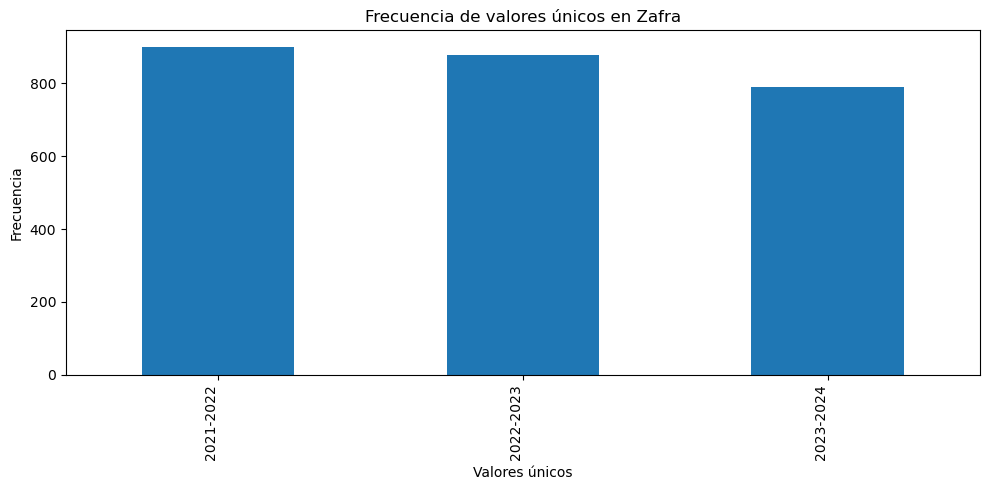

Resumen de Zona Longitudinal:
               Frecuencia  Porcentaje
centro oeste        1283        50.0
centro               856        33.4
este este            346        13.5
oeste                 39         1.5
centro este           33         1.3
este                   9         0.4


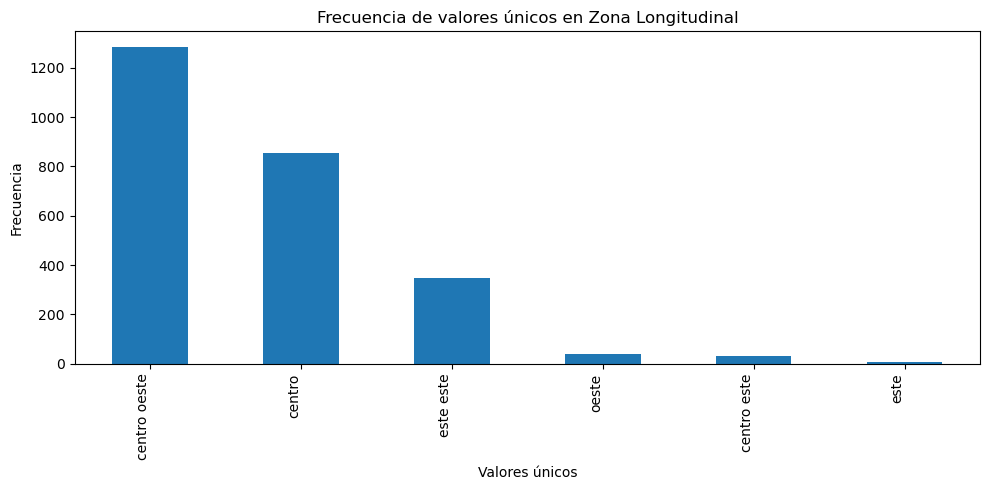

Resumen de Estrato:
          Frecuencia  Porcentaje
medio          1061        41.3
bajo            859        33.5
litoral         539        21.0
alto            107         4.2


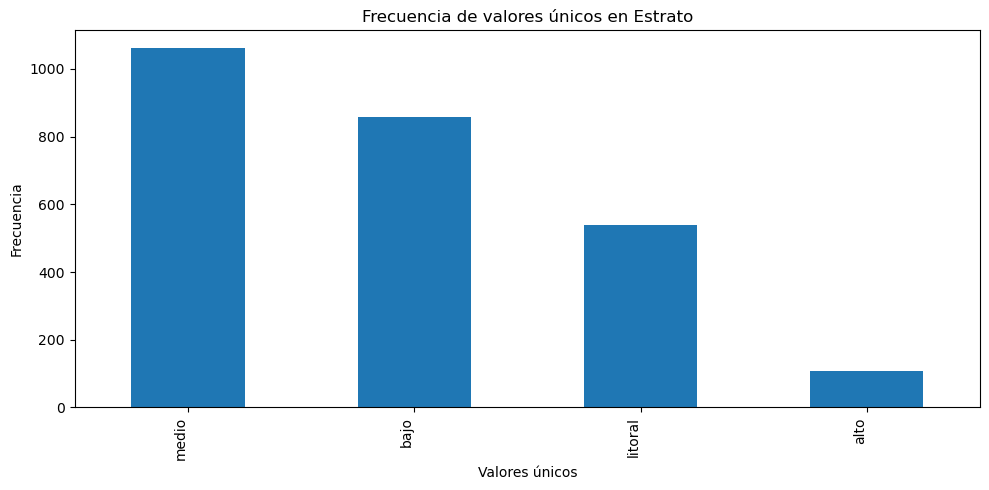

Resumen de Suelo:
                                                     Frecuencia  Porcentaje
typic hapludands medial                                    551        21.5
fluventic hapludolls franca fina y typic haplud...         262        10.2
typic hapludands medial/arcillosa                          219         8.5
vertic hapludalfs arcillosa                                216         8.4
fluventic hapludolls franca gruesa y andic hapl...         151         5.9
typic hapludolls franca fina/arenosa y typic us...          79         3.1
typic tropofluvents franca gruesa                           66         2.6
typic hapludands medial y typic humitropepts ar...          65         2.5
salorthidic haplustolls arenosa y typic ustipsa...          38         1.5
typic hapludolls franca fina/arenosa                        37         1.4
typic hapludands medial/esqueletal franca y typ...          36         1.4
typic humitropepts arcillosa                                32         1.2
andic 

C:\Users\djaimes\AppData\Local\Temp\ipykernel_33560\4178953576.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


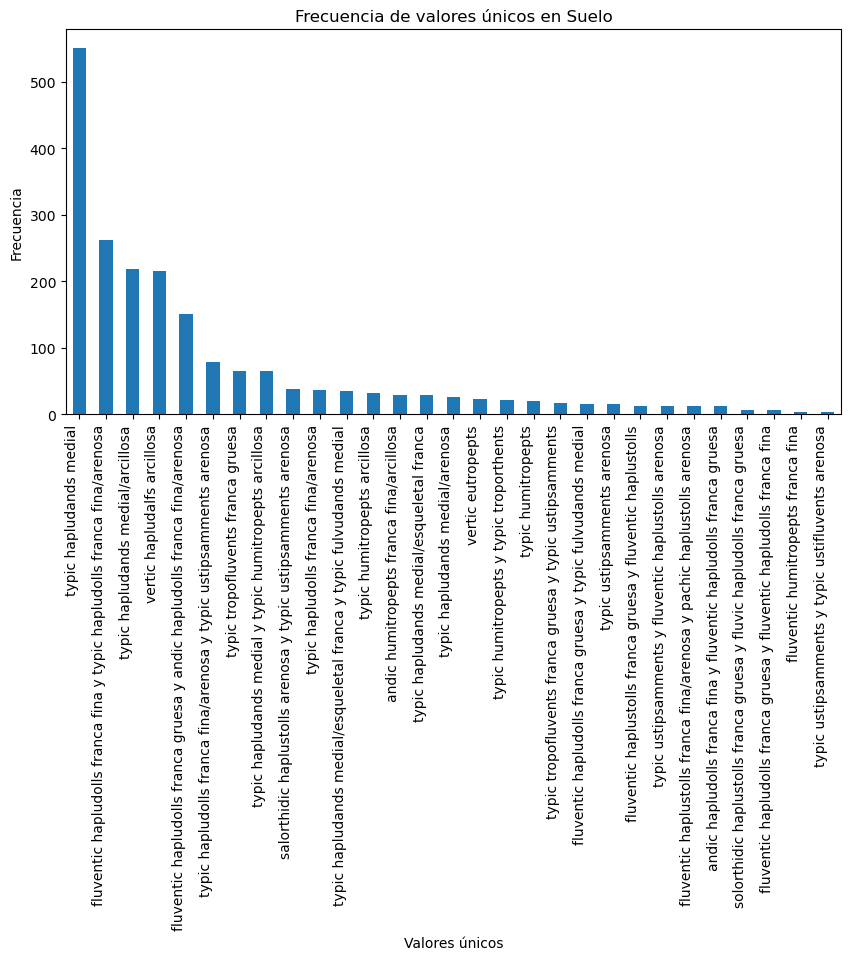

Resumen de Variedad:
                Frecuencia  Porcentaje
cg02-163              921        35.9
varias                464        18.1
cp73-1547             368        14.3
cp72-2086             160         6.2
cgmex10-26315         149         5.8
cg98-46               106         4.1
otras                  91         3.5
cg98-78                90         3.5
cg04-10295             56         2.2
cr87-339               52         2.0
cg00-102               51         2.0
cg10-044124            35         1.4
cg03-104               23         0.9


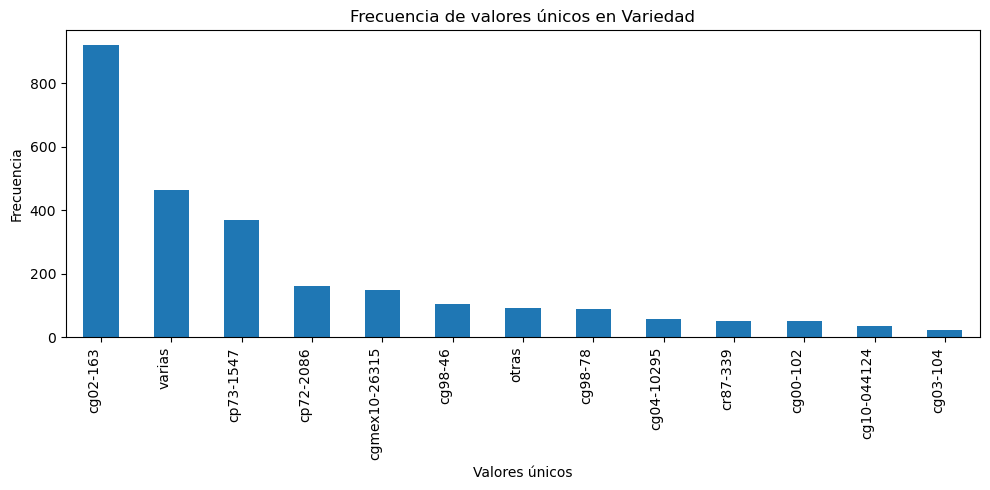

Resumen de textura:
                                   Frecuencia  Porcentaje
franca                                   700        27.3
arcillosa                                597        23.3
franca/franco arenosa                    501        19.5
arenosa                                  174         6.8
franco arcillosa, arcillosa               30         1.2
franco arcillosa, franco arenosa          12         0.5
franco arcillosa                           3         0.1


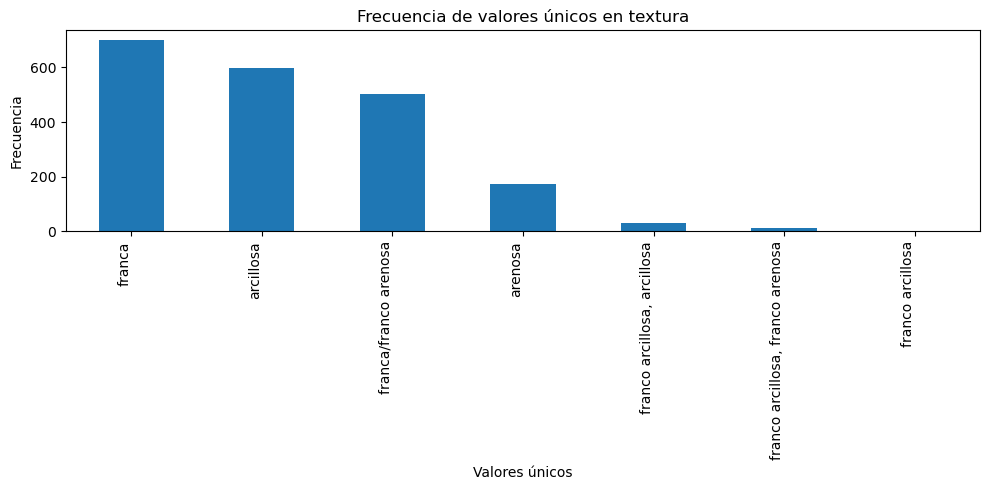

In [17]:

object_columns = manejo.select_dtypes(include='object')
summary_data = {}

for col in object_columns.columns:
    value_counts = object_columns[col].value_counts()
    percentage = round((value_counts / len(object_columns[col])) * 100,1)
    summary_data[col] = pd.DataFrame({'Frecuencia': value_counts, 'Porcentaje': percentage})


for col in object_columns.columns:
    print(f"Resumen de {col}:\n", summary_data[col])
    #summary_data es por cada col, es mejor renombrala!
    summary_df = summary_data[col].copy()
    plt.figure(figsize=(10, 5))
    summary_df['Frecuencia'].plot(kind='bar')
   
    plt.title(f'Frecuencia de valores únicos en {col}')
    plt.xlabel('Valores únicos')
    plt.ylabel('Frecuencia')
    
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()


aqui se puede abordar buenas practicas: redundancia en los valores que toma las caracteristicas...ejm: zafra sobra, soca sobra, etc
* relevancia en la informacion: estrato= alongitudinal?.... tabla de contingencia = chi cuadrado y cramers
* para la variable suelo hay muchas categorias, hay posibilidad de agrupacion?... ejemplo en buenamilpa teniamos  solo 5 categorias, arcilloso, franco, arenosos etc... esto aqui aplicaria?
* rn variedad pasa lo mismo.. pero hay una categoria varias... las de baja frecuencia se podria  meter ahi?
* soca es que la planta renace despues de una produccion... aqui se puede analizar otras cosas: aunque  ahorra este tiene  efectos en la pureza? en el TCH y TAH? implica mas nutrientes y ahi el ahorro se entenderá diferente?

## hay redundancia en la información categórica?
auie  se debe ver similitud, tablas de contingencia... explorar mas dar el significado 

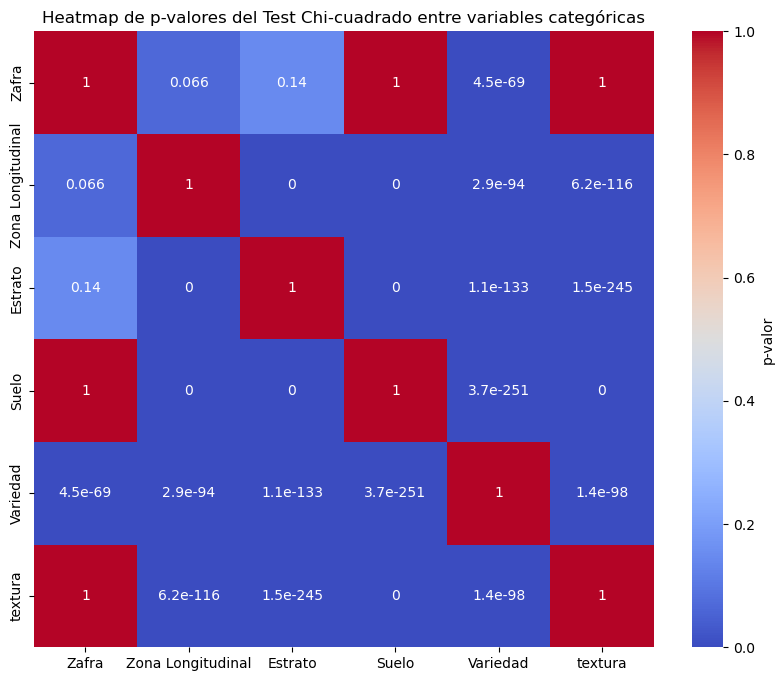

In [18]:
def chi2_test(df, col1, col2):
    confusion_matrix = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, ex = stats.chi2_contingency(confusion_matrix)
    return p

# Seleccionar solo las columnas categóricas del DataFrame `manejo`
categorical_columns = manejo.select_dtypes(include='object')

# Obtener los nombres de las columnas categóricas
cols = categorical_columns.columns

# Crear una matriz para almacenar los p-valores, inicialmente llenada con 1 (sin significancia)
p_value_matrix = pd.DataFrame(np.ones((len(cols), len(cols))), index=cols, columns=cols)

# Calcular el p-valor para cada par de columnas categóricas
for col1 in cols:
    for col2 in cols:
        if col1 != col2:
            p_value_matrix.loc[col1, col2] = chi2_test(manejo, col1, col2)  # Usar `manejo` en lugar de `df`

# Visualizar los resultados usando un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(p_value_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1, cbar_kws={'label': 'p-valor'})
plt.title("Heatmap de p-valores del Test Chi-cuadrado entre variables categóricas")
plt.show()


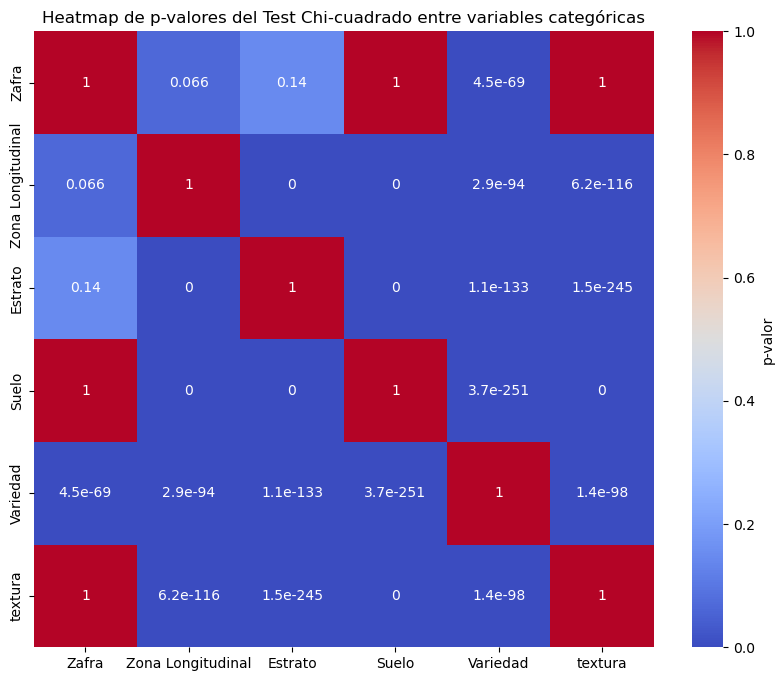

In [19]:
def chi2_test(df, col1, col2):
    confusion_matrix = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, ex = stats.chi2_contingency(confusion_matrix)
    return p

# Seleccionar solo las columnas categóricas del DataFrame `manejo`
categorical_columns = manejo.select_dtypes(include='object')

# Obtener los nombres de las columnas categóricas
cols = categorical_columns.columns

# Crear una matriz para almacenar los p-valores, inicialmente llenada con 1 (sin significancia)
p_value_matrix = pd.DataFrame(np.ones((len(cols), len(cols))), index=cols, columns=cols)

# Calcular el p-valor para cada par de columnas categóricas
for col1 in cols:
    for col2 in cols:
        if col1 != col2:
            p_value_matrix.loc[col1, col2] = chi2_test(manejo, col1, col2)  # Usar `manejo` en lugar de `df`

# Visualizar los resultados usando un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(p_value_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1, cbar_kws={'label': 'p-valor'})
plt.title("Heatmap de p-valores del Test Chi-cuadrado entre variables categóricas")
plt.show()


no se deberia quitar suelo con zona longitudinal y estrato... la zona longitudinal es como las lines horizontales a traves del pais y el estrato da cuent ade la altitud de y

# Analisis datos tipo fecha

## bloque de limpieza

In [20]:
manejo.select_dtypes(include='datetime')

,Fecha Inicial,Fecha de Cierre
0,2020-12-02 16:48:00,2021-11-07
1,2020-12-15 14:24:00,2021-11-07
2,2020-12-07 16:48:00,2021-11-06
3,2020-12-02 19:12:00,2021-11-05
4,2020-12-04 16:48:00,2021-11-06
...,...,...
2561,2023-05-23 19:12:00,2024-05-01
2562,2023-05-24 16:48:00,2024-05-01
2563,2023-05-02 02:24:00,2024-05-03
2564,2023-05-01 00:00:00,2024-05-01


fecha inicial tiene un formato diferente que el de cierre!

## Bloque de analisis
periodos, pfrecuencia, homogeneidad

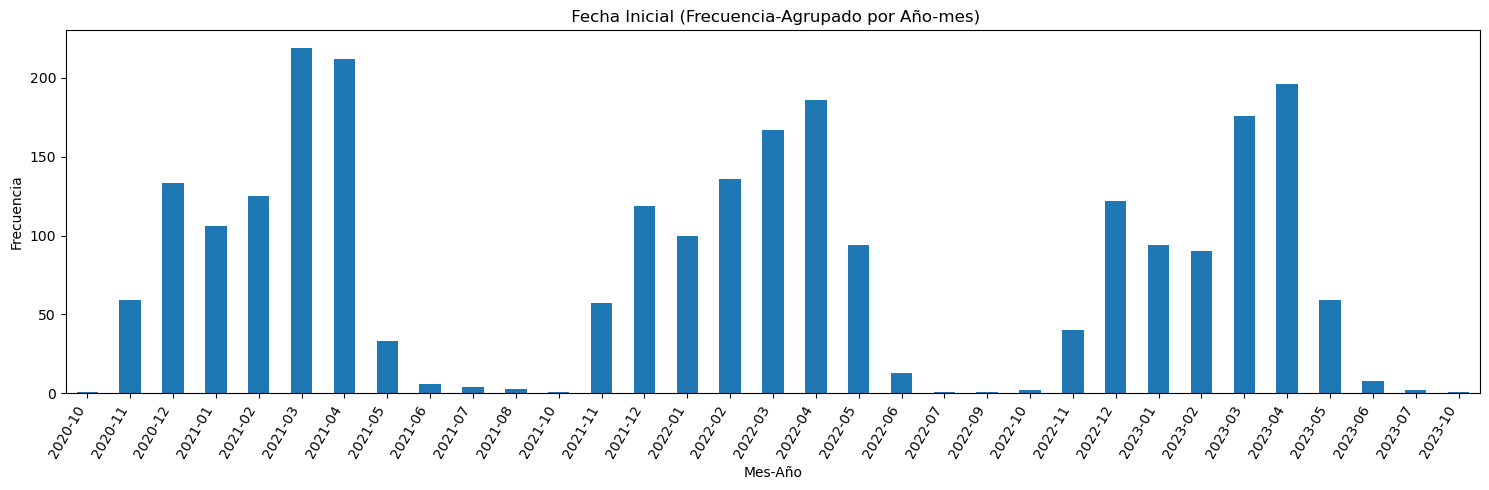

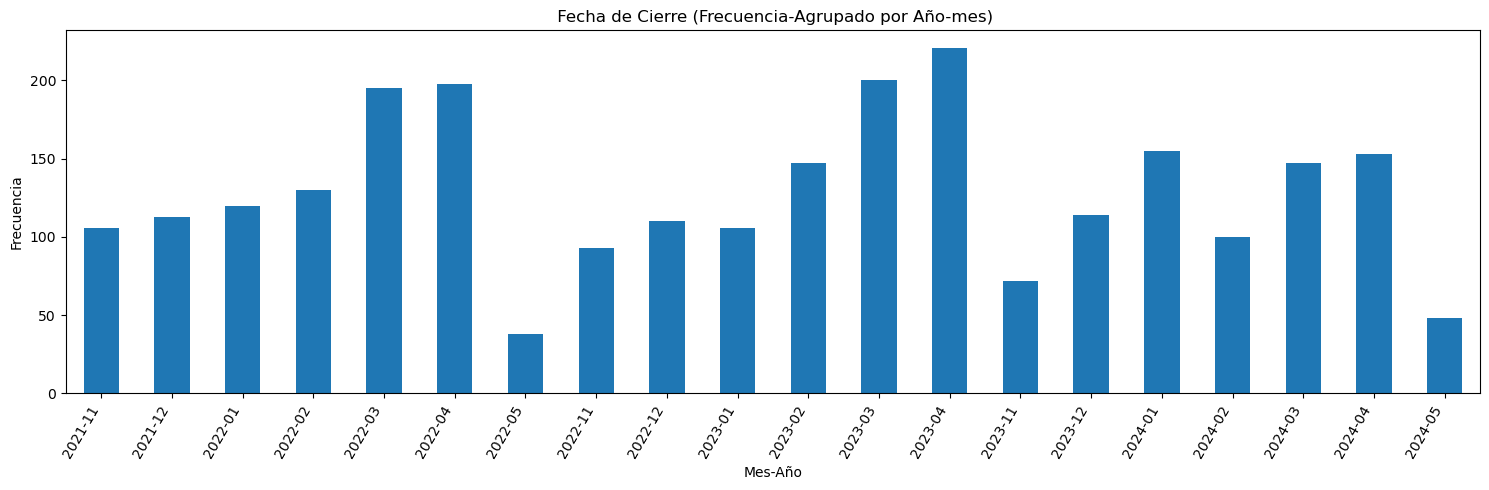

In [21]:

date_columns = manejo.select_dtypes(include='datetime')

unique_values_freq_date = {}

for col in date_columns.columns:
    # Agrupar por mes y año
    value_counts = date_columns[col].dt.to_period('M').value_counts()
    unique_values_freq_date[col] = value_counts

unique_values_df_date = pd.DataFrame(unique_values_freq_date)



for col in date_columns.columns:
    
    value_counts = date_columns[col].dt.to_period('M').value_counts()
    
    plt.figure(figsize=(15, 5))
    value_counts.sort_index().plot(kind='bar')  # Ordenar por fecha
    plt.title(f' {col} (Frecuencia-Agrupado por Año-mes)')
    plt.xlabel('Mes-Año')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()


se puede hacer aqui analisis de series de teimpo y homogenizacin de la serie

# Analisis datos númericoos

para este es mejor empezar con el bloque de analisis y luego hacer el de limpieza,... con el de analisis se da cuenta de los outliers por ejemplo

## Bloque de analisis... 
* analisis de distribuciones
* estadistics descriptivas

Resumen de ID-Unidad de producción (Agrupado en 10 intervalos):
                     Frecuencia  Porcentaje
(3850.053, 3945.7]         277        10.8
(3945.7, 4040.4]           274        10.7
(4040.4, 4135.1]           258        10.1
(4135.1, 4229.8]           253         9.9
(4229.8, 4324.5]           231         9.0
(4324.5, 4419.2]           257        10.0
(4419.2, 4513.9]           277        10.8
(4513.9, 4608.6]           228         8.9
(4608.6, 4703.3]           227         8.8
(4703.3, 4798.0]           284        11.1


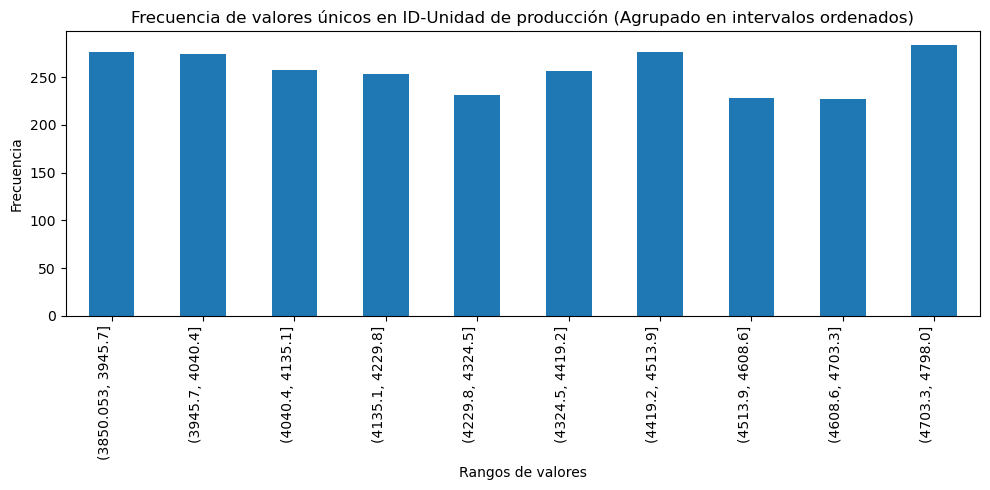

Resumen de Edad (meses) (Agrupado en 10 intervalos):
                 Frecuencia  Porcentaje
(2.18, 4.17]             1         0.0
(4.17, 6.14]             2         0.1
(6.14, 8.11]             7         0.3
(8.11, 10.08]           42         1.6
(10.08, 12.05]        1605        62.5
(12.05, 14.02]         900        35.1
(14.02, 15.99]           7         0.3
(15.99, 17.96]           1         0.0
(17.96, 19.93]           0         0.0
(19.93, 21.9]            1         0.0


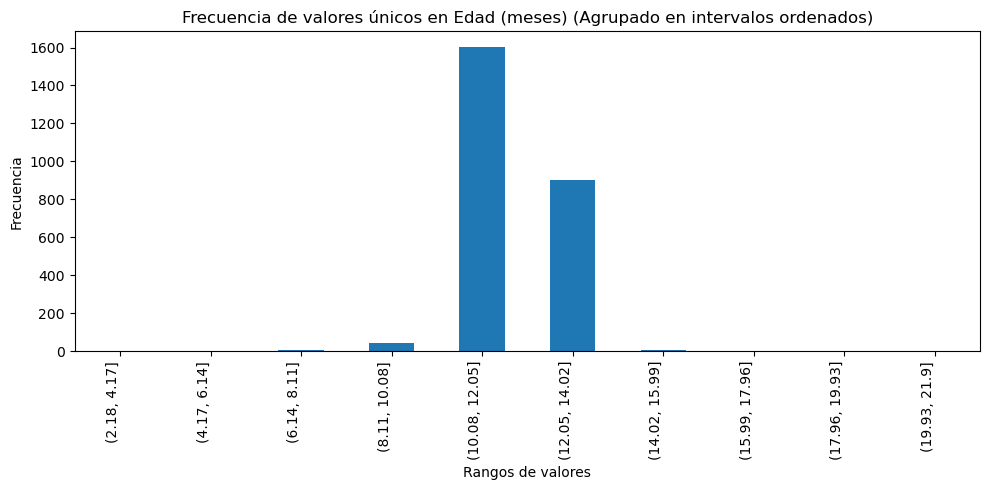

Resumen de Nitrogeno (Kg/ha) (Agrupado en 10 intervalos):
                     Frecuencia  Porcentaje
(-0.235, 23.518]           134         5.2
(23.518, 47.036]            46         1.8
(47.036, 70.554]           274        10.7
(70.554, 94.072]           671        26.1
(94.072, 117.59]           764        29.8
(117.59, 141.108]          501        19.5
(141.108, 164.626]         151         5.9
(164.626, 188.144]          13         0.5
(188.144, 211.662]           9         0.4
(211.662, 235.18]            3         0.1


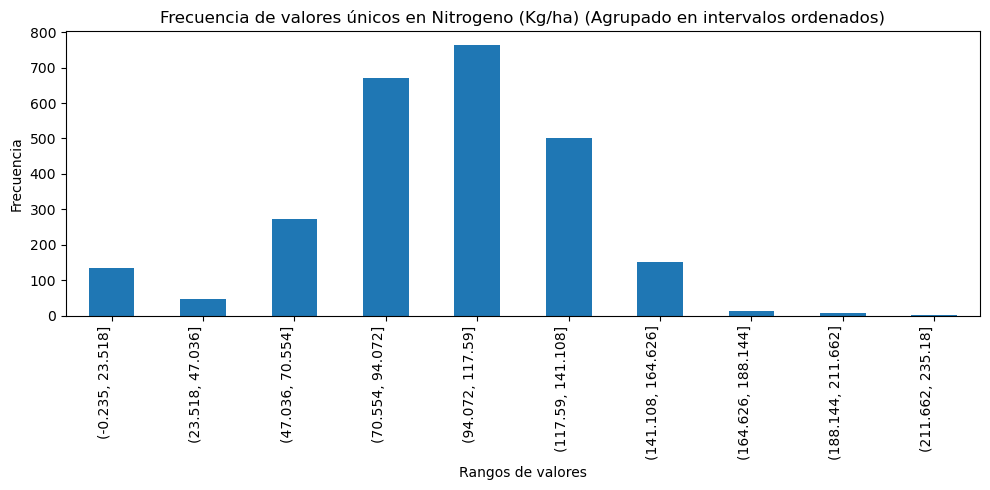

Resumen de Potasio (Kg/ha) (Agrupado en 10 intervalos):
                  Frecuencia  Porcentaje
(-0.0853, 8.53]        2433        94.8
(8.53, 17.06]             4         0.2
(17.06, 25.59]            2         0.1
(25.59, 34.12]            9         0.4
(34.12, 42.65]            7         0.3
(42.65, 51.18]            6         0.2
(51.18, 59.71]           32         1.2
(59.71, 68.24]           48         1.9
(68.24, 76.77]           13         0.5
(76.77, 85.3]            12         0.5


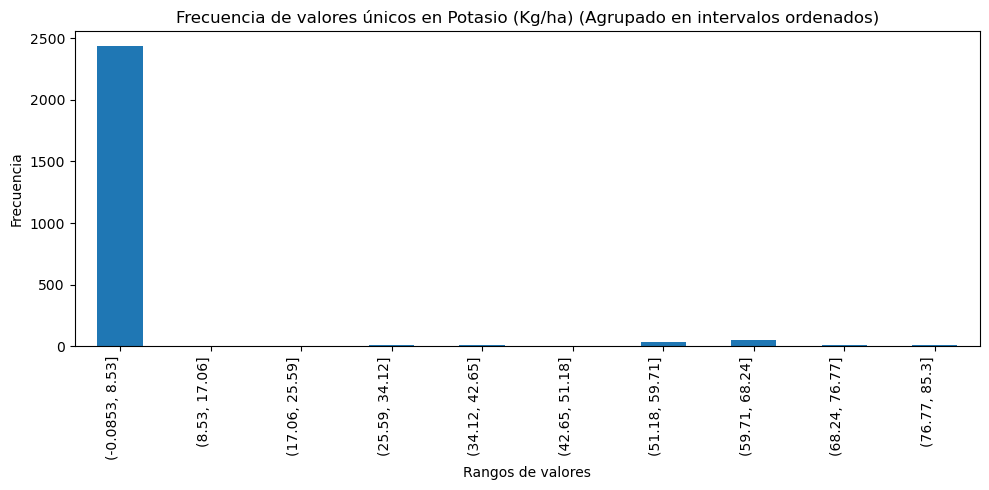

Resumen de Fósforo (Kg/ha) (Agrupado en 10 intervalos):
                    Frecuencia  Porcentaje
(-0.113, 11.326]         2150        83.8
(11.326, 22.652]           14         0.5
(22.652, 33.978]           30         1.2
(33.978, 45.304]          154         6.0
(45.304, 56.63]            50         1.9
(56.63, 67.956]           128         5.0
(67.956, 79.282]           11         0.4
(79.282, 90.608]           23         0.9
(90.608, 101.934]           3         0.1
(101.934, 113.26]           3         0.1


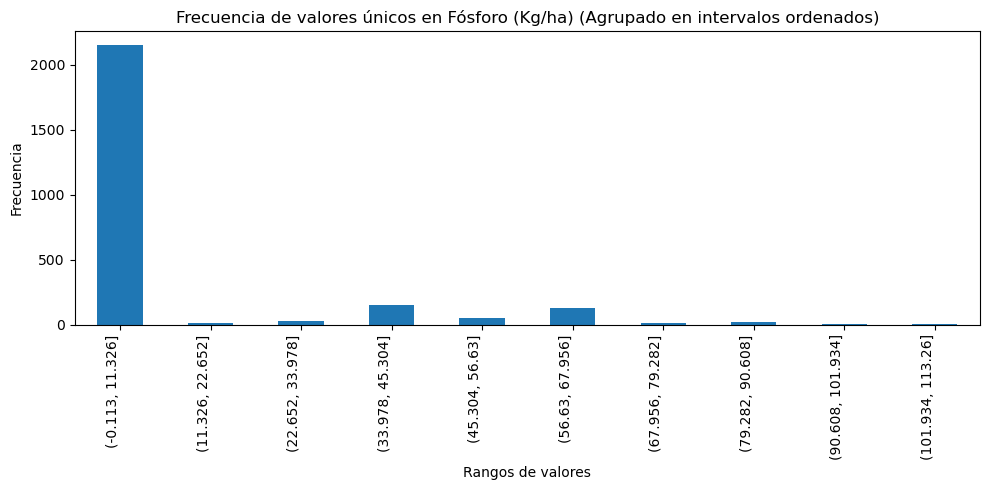

Resumen de TCH (Agrupado en 10 intervalos):
                     Frecuencia  Porcentaje
(29.35, 50.542]             45         1.8
(50.542, 71.524]           223         8.7
(71.524, 92.506]           524        20.4
(92.506, 113.488]          843        32.9
(113.488, 134.47]          615        24.0
(134.47, 155.452]          260        10.1
(155.452, 176.434]          52         2.0
(176.434, 197.416]           3         0.1
(197.416, 218.398]           0         0.0
(218.398, 239.38]            1         0.0


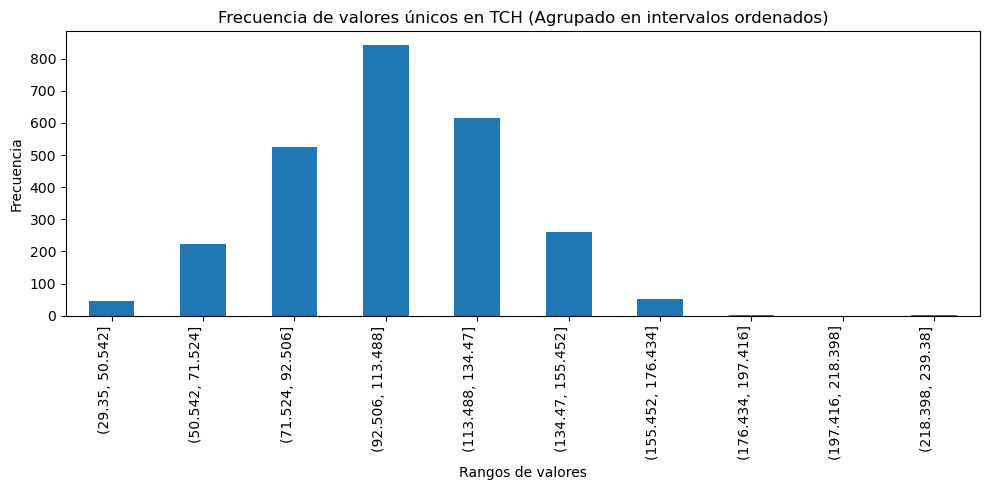

Resumen de Rendimiento (%) (Agrupado en 10 intervalos):
                  Frecuencia  Porcentaje
(7.002, 7.785]            4         0.2
(7.785, 8.56]             9         0.4
(8.56, 9.335]            28         1.1
(9.335, 10.11]          278        10.8
(10.11, 10.885]         719        28.0
(10.885, 11.66]         939        36.6
(11.66, 12.435]         495        19.3
(12.435, 13.21]          81         3.2
(13.21, 13.985]           6         0.2
(13.985, 14.76]           7         0.3


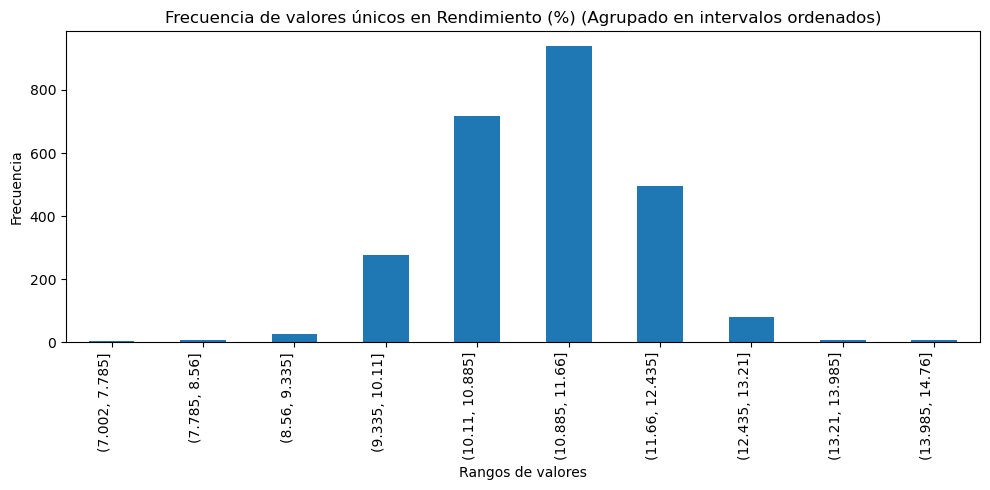

Resumen de TAH (Agrupado en 10 intervalos):
                   Frecuencia  Porcentaje
(3.316, 5.718]            47         1.8
(5.718, 8.096]           237         9.2
(8.096, 10.474]          619        24.1
(10.474, 12.852]         868        33.8
(12.852, 15.23]          578        22.5
(15.23, 17.608]          183         7.1
(17.608, 19.986]          29         1.1
(19.986, 22.364]           4         0.2
(22.364, 24.742]           0         0.0
(24.742, 27.12]            1         0.0


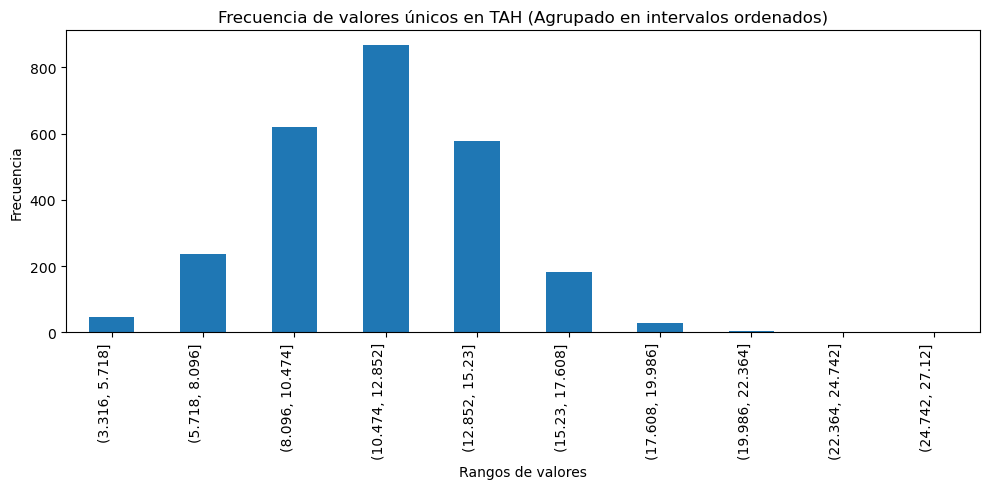

Resumen de Pureza (%) (Agrupado en 10 intervalos):
                   Frecuencia  Porcentaje
(77.042, 78.819]           1         0.0
(78.819, 80.578]          11         0.4
(80.578, 82.337]          41         1.6
(82.337, 84.096]         124         4.8
(84.096, 85.855]         341        13.3
(85.855, 87.614]         768        29.9
(87.614, 89.373]         947        36.9
(89.373, 91.132]         301        11.7
(91.132, 92.891]          30         1.2
(92.891, 94.65]            2         0.1


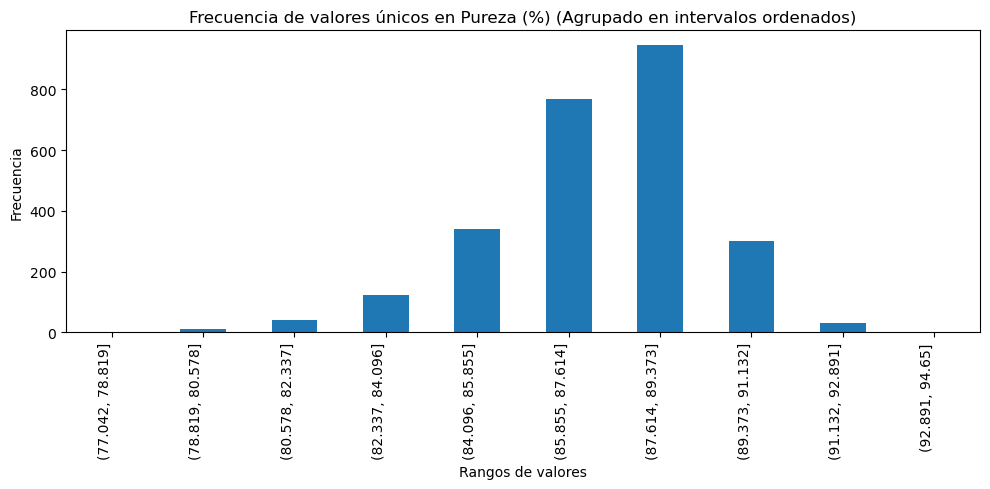

Resumen de Radiación global acumulada (W/m2) (Agrupado en 10 intervalos):
                           Frecuencia  Porcentaje
(-158.301, 15830.099]            195         7.6
(15830.099, 31660.199]             0         0.0
(31660.199, 47490.298]             6         0.2
(47490.298, 63320.397]            20         0.8
(63320.397, 79150.497]          1088        42.4
(79150.497, 94980.596]          1234        48.1
(94980.596, 110810.695]           21         0.8
(110810.695, 126640.795]           1         0.0
(126640.795, 142470.894]           0         0.0
(142470.894, 158300.993]           1         0.0


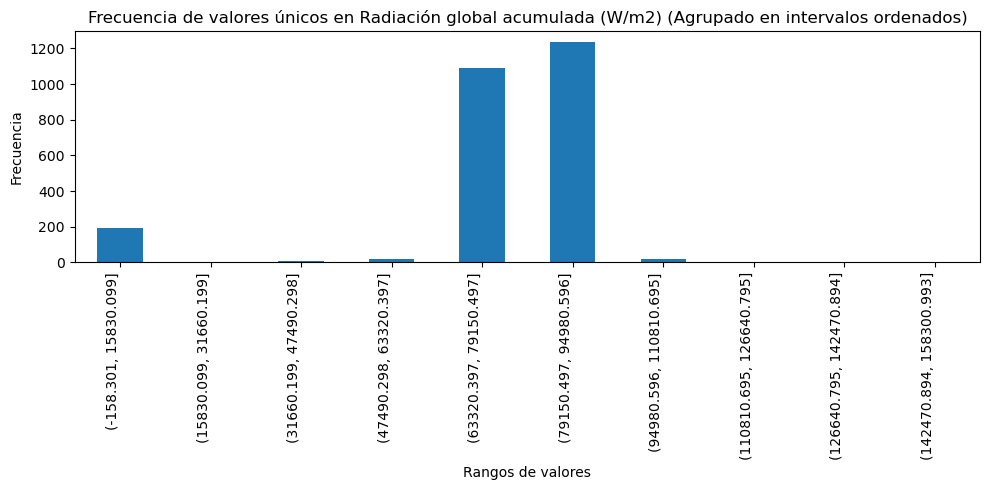

Resumen de Precipitación acumulada por ciclo/Estación (mm) (Agrupado en 10 intervalos):
                     Frecuencia  Porcentaje
(-5.29, 528.96]            196         7.6
(528.96, 1057.92]          143         5.6
(1057.92, 1586.88]         536        20.9
(1586.88, 2115.84]         873        34.0
(2115.84, 2644.8]           43         1.7
(2644.8, 3173.76]          214         8.3
(3173.76, 3702.72]         284        11.1
(3702.72, 4231.68]          26         1.0
(4231.68, 4760.64]         193         7.5
(4760.64, 5289.6]           58         2.3


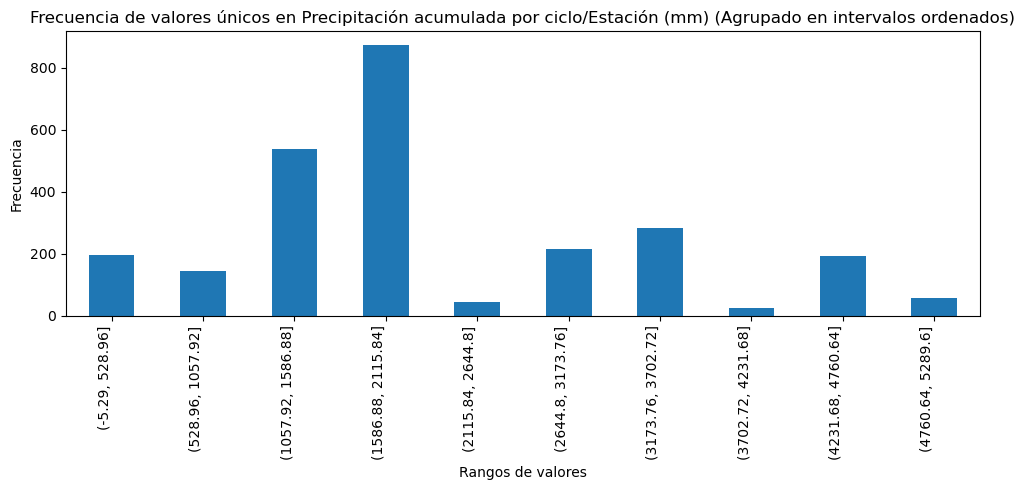

Resumen de Temperatura mínima (30DAC) °C (Agrupado en 10 intervalos):
                   Frecuencia  Porcentaje
(-0.0257, 2.572]         194         7.6
(2.572, 5.144]             0         0.0
(5.144, 7.716]             0         0.0
(7.716, 10.288]            0         0.0
(10.288, 12.86]            0         0.0
(12.86, 15.432]            0         0.0
(15.432, 18.004]          65         2.5
(18.004, 20.576]         664        25.9
(20.576, 23.148]        1258        49.0
(23.148, 25.72]          385        15.0


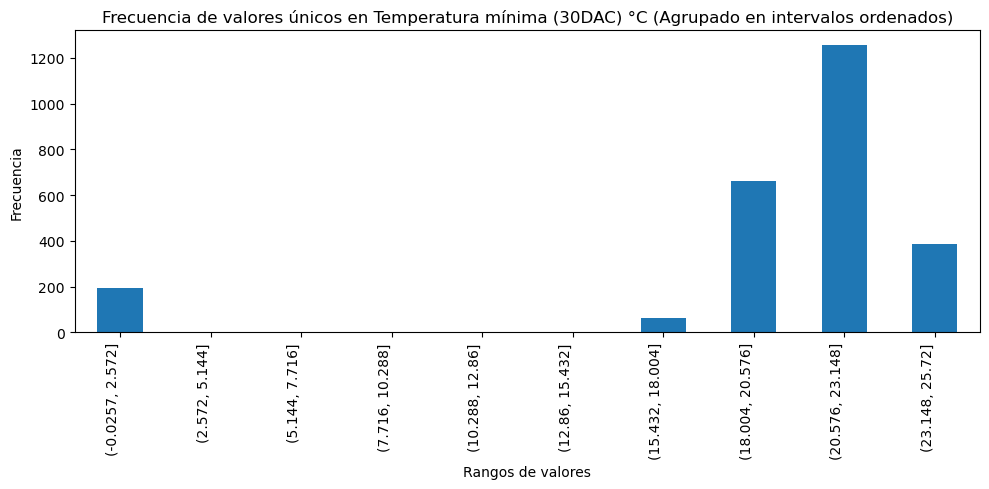

Resumen de Temperatura máxima (30DAC) °C (Agrupado en 10 intervalos):
                   Frecuencia  Porcentaje
(-0.0387, 3.872]         194         7.6
(3.872, 7.744]             0         0.0
(7.744, 11.616]            0         0.0
(11.616, 15.488]           0         0.0
(15.488, 19.36]            0         0.0
(19.36, 23.232]            0         0.0
(23.232, 27.104]           0         0.0
(27.104, 30.976]           0         0.0
(30.976, 34.848]        1009        39.3
(34.848, 38.72]         1363        53.1


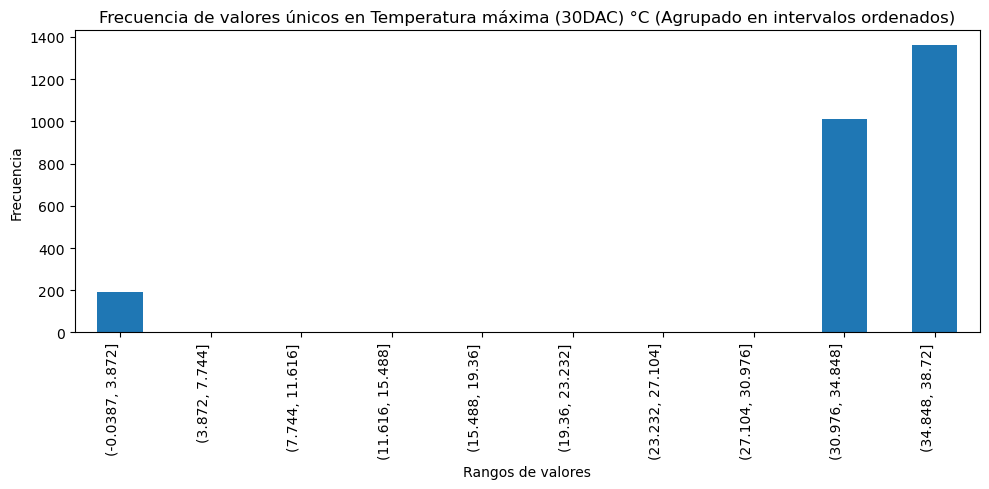

Resumen de Amplitud térmica (30DAC) °C (Agrupado en 10 intervalos):
                   Frecuencia  Porcentaje
(-0.019, 1.904]          194         7.6
(1.904, 3.809]             0         0.0
(3.809, 5.713]             0         0.0
(5.713, 7.617]             0         0.0
(7.617, 9.522]            44         1.7
(9.522, 11.426]          237         9.2
(11.426, 13.33]          708        27.6
(13.33, 15.235]          903        35.2
(15.235, 17.139]         334        13.0
(17.139, 19.043]         146         5.7


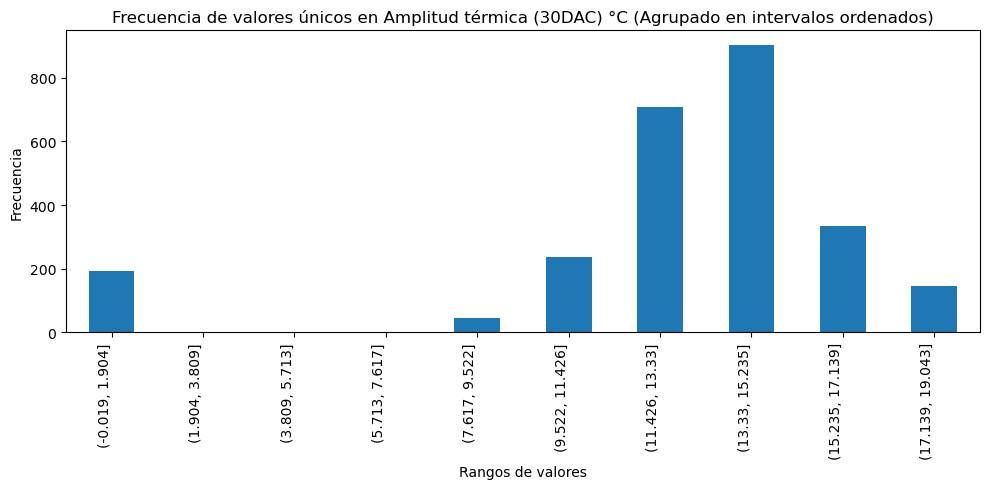

Resumen de Precipitación agosto (mm) (Agrupado en 10 intervalos):
                   Frecuencia  Porcentaje
(-0.936, 93.64]          194         7.6
(93.64, 187.28]          569        22.2
(187.28, 280.92]         481        18.7
(280.92, 374.56]         519        20.2
(374.56, 468.2]           35         1.4
(468.2, 561.84]          252         9.8
(561.84, 655.48]           0         0.0
(655.48, 749.12]         374        14.6
(749.12, 842.76]           0         0.0
(842.76, 936.4]          142         5.5


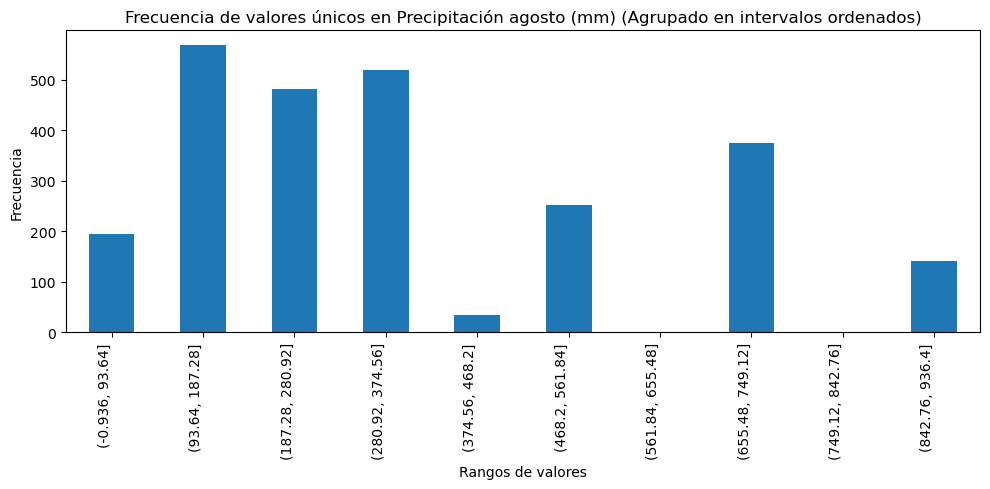

Resumen de Iniciación_radiacion_acumulada (Agrupado en 10 intervalos):
                         Frecuencia  Porcentaje
(-12.824, 1282.38]             241         9.4
(1282.38, 2564.759]              0         0.0
(2564.759, 3847.139]             0         0.0
(3847.139, 5129.518]             0         0.0
(5129.518, 6411.898]             0         0.0
(6411.898, 7694.278]             2         0.1
(7694.278, 8976.657]            76         3.0
(8976.657, 10259.037]         1035        40.3
(10259.037, 11541.416]        1000        39.0
(11541.416, 12823.796]         212         8.3


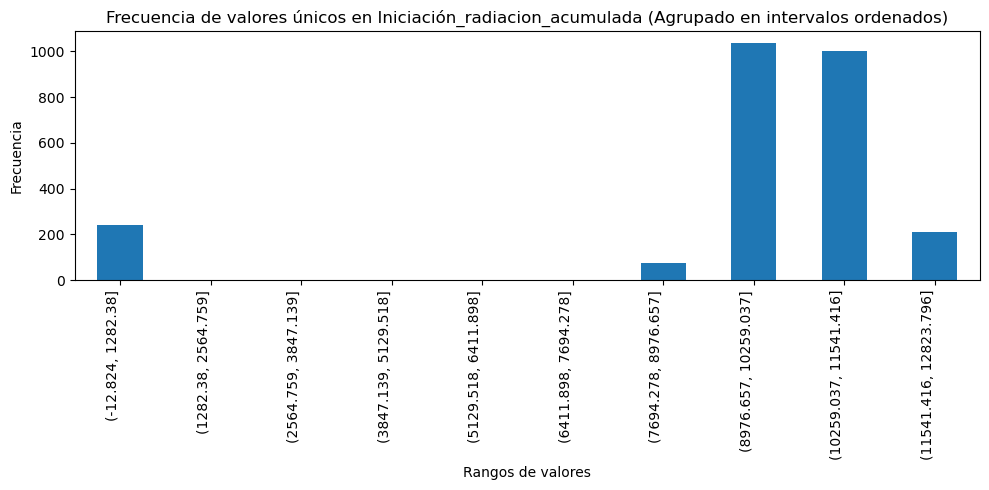

Resumen de Macollamiento_radiacion_acumulada (Agrupado en 10 intervalos):
                         Frecuencia  Porcentaje
(-18.02, 1801.953]             241         9.4
(1801.953, 3603.907]             0         0.0
(3603.907, 5405.86]              0         0.0
(5405.86, 7207.813]              0         0.0
(7207.813, 9009.767]             0         0.0
(9009.767, 10811.72]             0         0.0
(10811.72, 12613.673]           70         2.7
(12613.673, 14415.627]         651        25.4
(14415.627, 16217.58]         1465        57.1
(16217.58, 18019.533]          139         5.4


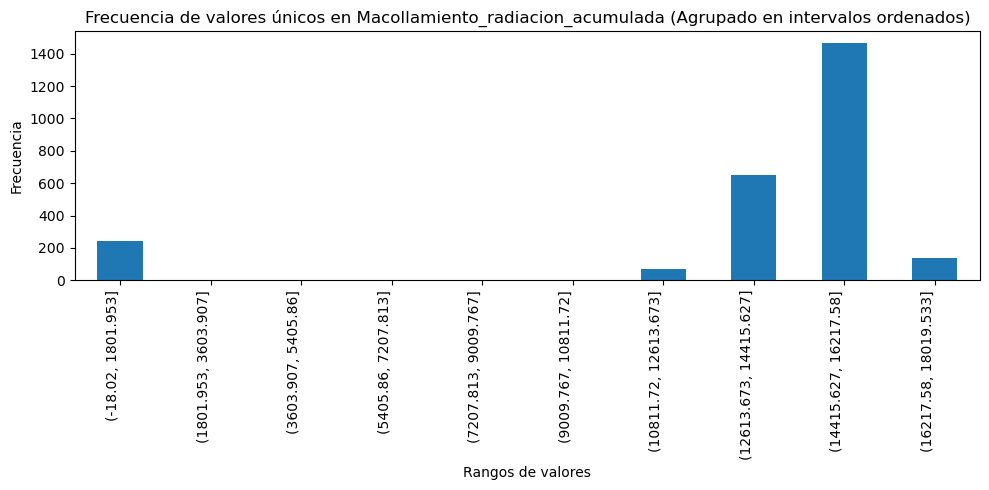

Resumen de Elongación I_radiacion_acumulada (Agrupado en 10 intervalos):
                         Frecuencia  Porcentaje
(-35.077, 3507.746]            241         9.4
(3507.746, 7015.491]             0         0.0
(7015.491, 10523.237]            0         0.0
(10523.237, 14030.983]           0         0.0
(14030.983, 17538.728]           0         0.0
(17538.728, 21046.474]           0         0.0
(21046.474, 24554.219]           0         0.0
(24554.219, 28061.965]         137         5.3
(28061.965, 31569.711]        1281        49.9
(31569.711, 35077.456]         907        35.3


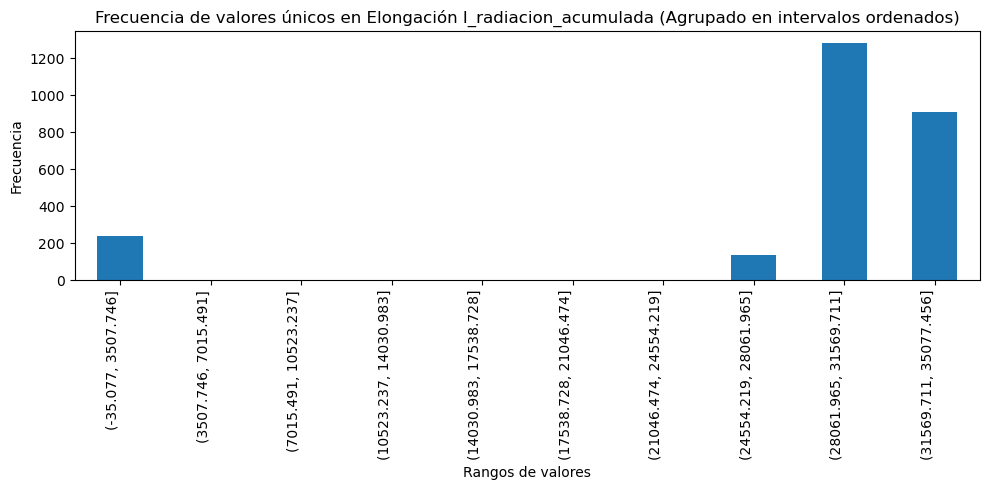

Resumen de Elongacíon II_radiacion_acumulada (Agrupado en 10 intervalos):
                         Frecuencia  Porcentaje
(-17.39, 1738.952]             241         9.4
(1738.952, 3477.904]             0         0.0
(3477.904, 5216.855]             0         0.0
(5216.855, 6955.807]             0         0.0
(6955.807, 8694.759]             0         0.0
(8694.759, 10433.711]            0         0.0
(10433.711, 12172.662]          29         1.1
(12172.662, 13911.614]         510        19.9
(13911.614, 15650.566]        1611        62.8
(15650.566, 17389.518]         175         6.8


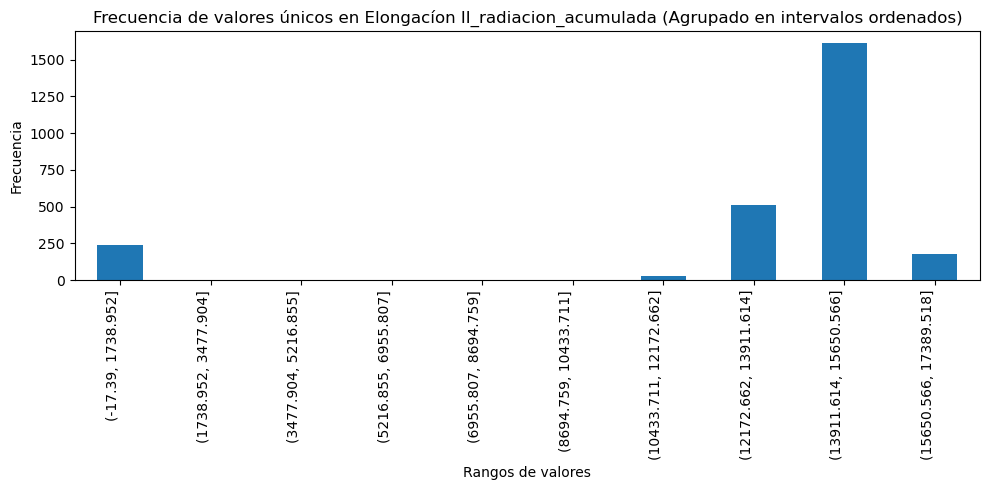

Resumen de Maduración_radiacion_acumulada (Agrupado en 10 intervalos):
                         Frecuencia  Porcentaje
(-79.602, 7960.165]           1080        42.1
(7960.165, 15920.329]         1322        51.5
(15920.329, 23880.494]         153         6.0
(23880.494, 31840.658]           8         0.3
(31840.658, 39800.823]           1         0.0
(39800.823, 47760.987]           1         0.0
(47760.987, 55721.152]           0         0.0
(55721.152, 63681.316]           0         0.0
(63681.316, 71641.481]           0         0.0
(71641.481, 79601.645]           1         0.0


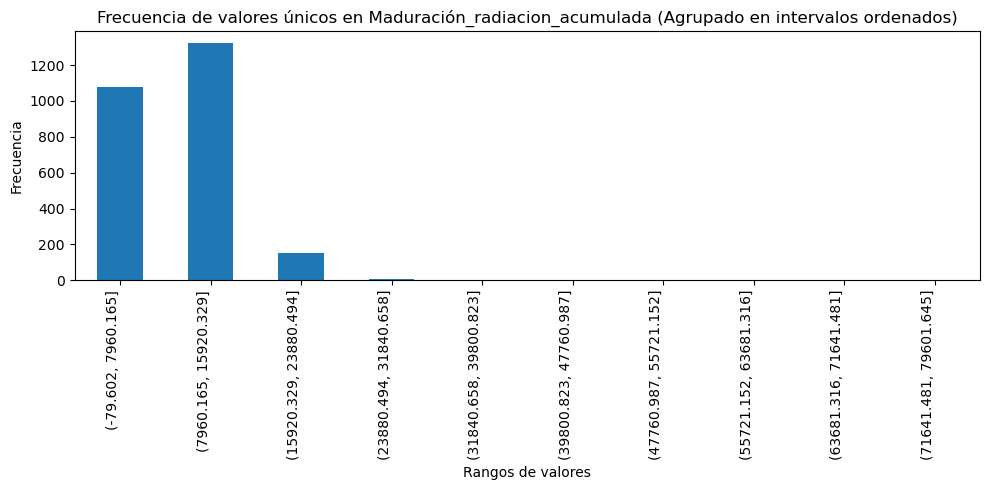

Resumen de Iniciación_prec_acumulada (Agrupado en 10 intervalos):
                   Frecuencia  Porcentaje
(-1.142, 114.2]         1497        58.3
(114.2, 228.4]           404        15.7
(228.4, 342.6]           233         9.1
(342.6, 456.8]            99         3.9
(456.8, 571.0]            93         3.6
(571.0, 685.2]           103         4.0
(685.2, 799.4]            87         3.4
(799.4, 913.6]            46         1.8
(913.6, 1027.8]            3         0.1
(1027.8, 1142.0]           1         0.0


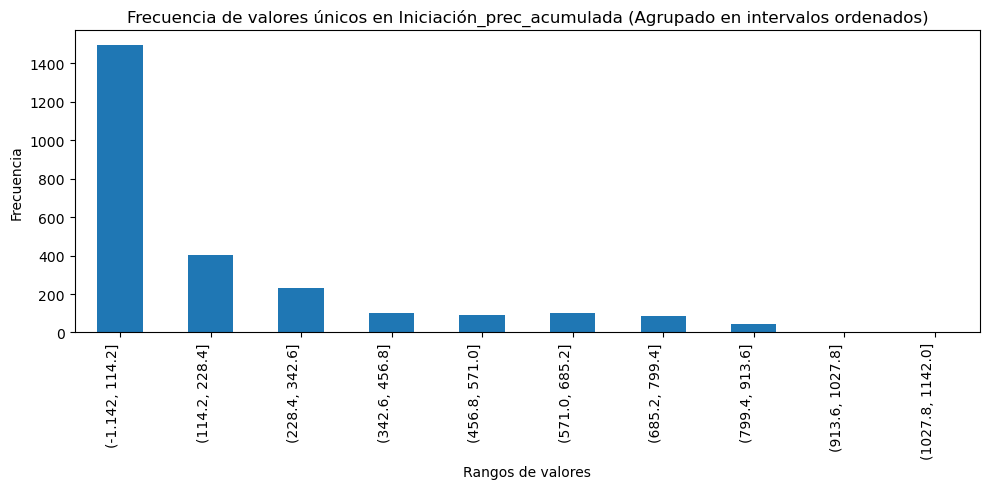

Resumen de Macollamiento_prec_acumulada (Agrupado en 10 intervalos):
                   Frecuencia  Porcentaje
(-1.503, 150.3]          808        31.5
(150.3, 300.6]           420        16.4
(300.6, 450.9]           413        16.1
(450.9, 601.2]           244         9.5
(601.2, 751.5]           215         8.4
(751.5, 901.8]           123         4.8
(901.8, 1052.1]          138         5.4
(1052.1, 1202.4]         146         5.7
(1202.4, 1352.7]          24         0.9
(1352.7, 1503.0]          35         1.4


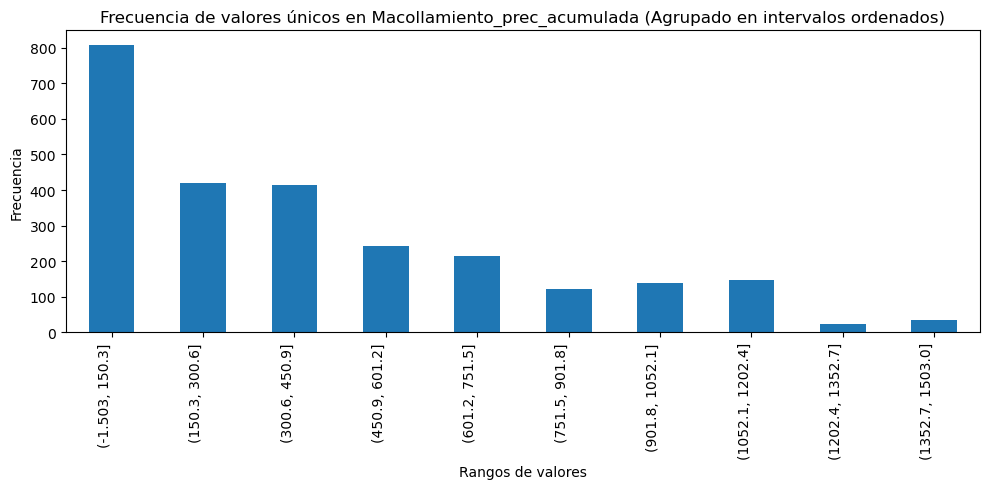

Resumen de Elongación I_prec_acumulada (Agrupado en 10 intervalos):
                     Frecuencia  Porcentaje
(-3.323, 332.34]           261        10.2
(332.34, 664.68]           209         8.1
(664.68, 997.02]           679        26.5
(997.02, 1329.36]          457        17.8
(1329.36, 1661.7]          350        13.6
(1661.7, 1994.04]          181         7.1
(1994.04, 2326.38]         220         8.6
(2326.38, 2658.72]          84         3.3
(2658.72, 2991.06]          96         3.7
(2991.06, 3323.4]           29         1.1


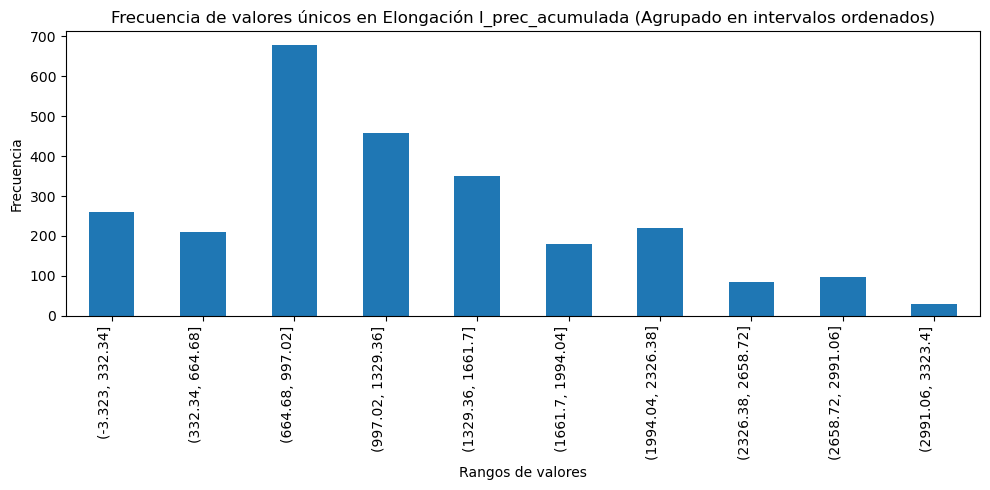

Resumen de Elongacíon II_prec_acumulada (Agrupado en 10 intervalos):
                     Frecuencia  Porcentaje
(-1.664, 166.42]          1678        65.4
(166.42, 332.84]           209         8.1
(332.84, 499.26]           129         5.0
(499.26, 665.68]           195         7.6
(665.68, 832.1]             92         3.6
(832.1, 998.52]             78         3.0
(998.52, 1164.94]           68         2.7
(1164.94, 1331.36]          79         3.1
(1331.36, 1497.78]          32         1.2
(1497.78, 1664.2]            6         0.2


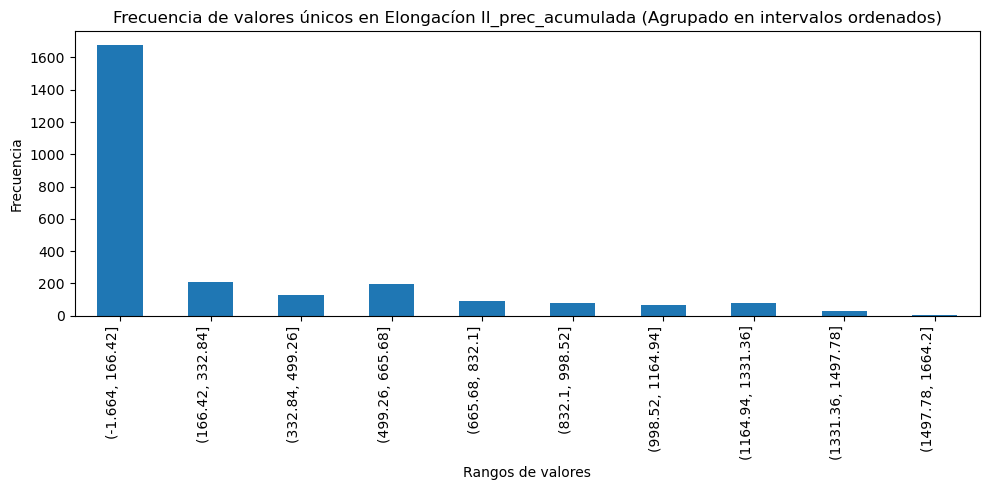

Resumen de Maduración_prec_acumulada (Agrupado en 10 intervalos):
                     Frecuencia  Porcentaje
(-1.974, 197.38]          2301        89.7
(197.38, 394.76]           190         7.4
(394.76, 592.14]            42         1.6
(592.14, 789.52]            15         0.6
(789.52, 986.9]             10         0.4
(986.9, 1184.28]             3         0.1
(1184.28, 1381.66]           4         0.2
(1381.66, 1579.04]           0         0.0
(1579.04, 1776.42]           0         0.0
(1776.42, 1973.8]            1         0.0


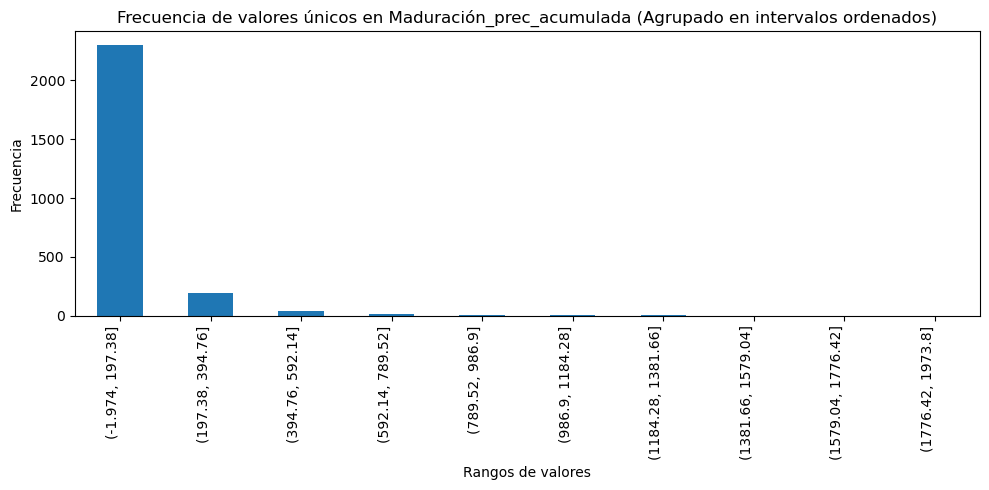

In [22]:

numeric_columns = manejo.select_dtypes(include=['int64', 'float64'])
n_bins = 10

summary_data_numeric = {}

for col in numeric_columns.columns:
    value_groups = pd.cut(numeric_columns[col], bins=n_bins)
    value_counts = value_groups.value_counts().sort_index()  # Ordenar por intervalos
    total_count = len(numeric_columns[col])
    percentage = round((value_counts / total_count) * 100,1)
    summary_data_numeric[col] = pd.DataFrame({'Frecuencia': value_counts, 'Porcentaje': percentage})


for col in numeric_columns.columns:
    summary_df = summary_data_numeric[col]
    print(f"Resumen de {col} (Agrupado en {n_bins} intervalos):\n", summary_df)
    plt.figure(figsize=(10, 5))
    summary_df['Frecuencia'].plot(kind='bar')
   
    plt.title(f'Frecuencia de valores únicos en {col} (Agrupado en intervalos ordenados)')
    plt.xlabel('Rangos de valores')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()


Hallazgos:
* Edad: hay desbalance significativo, ya que la mayoria de las instancias entan entre los 10 hasta los 14 los demas tiene muy pocos casos.... yo quitaria los pocos casos pues al tener povca representabilidad el modelo no tendra la posibilidad de aprender de ellos, es decir sacar patrones de ellos.... evita el sobreajuste (el modelo no se esforzara a aprender con pocos ejemplso)... se pierde representabilidad para esas edades!!
* hay valores negativos paraa precipitacion... esto no tiene sentido
* hay valores negativos pra nitrogeno, potasio y fosforo?, no! por el el efecto de bin se toma desde valores negativos pero viendolo individual esto no pasa
* Una posible variable objetivo TCH (toneladas de caña) aunque tiene una dsitribución casi normal hay poca representabilidad despues de 13 y antes de 8.56, si se colocan más valores "el modelo podría sesgarse hacia los intervalos con más observaciones y no aprender patrones significativos para los intervalos con menos observaciones"-->  Esto puede llevar a un sobreajuste en las clases dominantes y a un subajuste en los valores extremos o poco representados (puede considerarse ruido).... que se puede hacer (eliminarlos, agrupar (convertir la variable objetivo en categorica), oversampling)
* Iniciación	Macollamiento	Elongación I	Elongacíon II	Maduración	Iniciación	Macollamiento	Elongación I	Elongacíon II	Maduración... porque se repiten? tiene valores diferentes!!... si estas son como fases de crecimiento las unidades serian en dias?





## BLOQUE de limpieza

* las edades quedaran de 8.11 haasta 14.02
* en TCH se quitará los extremos que no son representativos  osea 177 en adelante
* en TAH se quitaran de 20 en adelante



In [23]:
manejo.select_dtypes(include=['int64', 'float64'])

,ID-Unidad de producción,Edad (meses),Nitrogeno (Kg/ha),Potasio (Kg/ha),Fósforo (Kg/ha),TCH,Rendimiento (%),TAH,Pureza (%),Radiación global acumulada (W/m2),...,Iniciación_radiacion_acumulada,Macollamiento_radiacion_acumulada,Elongación I_radiacion_acumulada,Elongacíon II_radiacion_acumulada,Maduración_radiacion_acumulada,Iniciación_prec_acumulada,Macollamiento_prec_acumulada,Elongación I_prec_acumulada,Elongacíon II_prec_acumulada,Maduración_prec_acumulada
0,4425,11.31,76.80,0.0,0.00,53.09,10.91,5.79,91.50,71508.07427,...,9079.31879,14643.80530,29674.21986,13180.99905,4929.73127,49.6,139.6,1530.4,1214.0,337.6
1,4427,10.88,78.57,0.0,0.00,69.12,10.18,7.04,91.20,68918.21800,...,9525.05316,14732.73653,29044.09592,13151.86988,2464.46251,46.6,141.0,1826.2,1176.8,77.6
2,4428,11.11,81.80,0.0,0.00,62.88,10.01,6.29,90.06,70350.41280,...,9341.11566,14685.36571,29436.46675,13171.15321,3716.31147,46.8,140.8,1677.4,1192.6,208.6
3,4430,11.24,81.80,0.0,0.00,67.47,11.07,7.47,90.27,71021.27947,...,9079.31879,14643.80530,29674.21986,13180.99905,4442.93647,49.6,139.6,1530.4,1214.0,335.4
4,4431,11.21,81.80,0.0,0.00,62.72,9.46,5.93,88.53,70938.46384,...,9205.68441,14695.97821,29558.70945,13221.63967,4256.45210,47.0,139.6,1596.0,1170.2,313.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2561,4338,11.44,92.47,0.0,0.00,118.73,10.77,12.79,84.68,77805.93263,...,9901.20319,15166.10844,30857.89281,15176.55421,6704.17398,279.0,649.6,917.6,0.0,24.0
2562,4340,11.41,77.45,0.0,0.00,126.60,10.64,13.47,85.11,77569.51596,...,9883.88860,15224.36574,30826.34593,15108.09692,6526.81877,251.4,632.2,917.6,0.0,24.0
2563,4351,12.23,92.23,0.0,0.00,64.78,10.91,7.07,84.94,83131.02953,...,10118.91150,14844.08449,31023.99906,15094.92090,12049.11358,267.2,589.8,1119.0,0.0,24.0
2564,4620,12.20,114.59,0.0,0.00,74.37,9.94,7.39,84.45,85633.28883,...,10614.51877,15698.65006,31669.64486,15651.54280,13050.92297,215.2,339.4,681.4,0.2,50.8


In [27]:
manejo = manejo[(manejo['Edad (meses)'] >= 8.11) & (manejo['Edad (meses)'] <= 14.02)].reset_index(drop=True)
len(manejo)

2547

In [30]:
manejo = manejo[manejo['TCH'] < 177].reset_index(drop=True)
len(manejo)

2543

In [31]:
manejo = manejo[manejo['TAH'] < 20].reset_index(drop=True)
len(manejo)

2540

## Posibles variables objetivos: TCH y TAH... 

<Axes: >

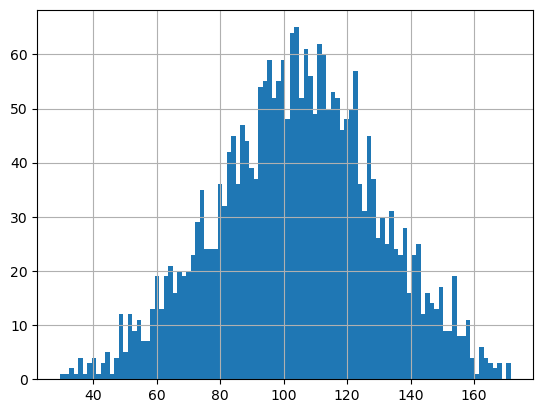

In [33]:
manejo.TCH.hist(bins=100)

In [34]:


fig = go.Figure(data=go.Violin(y=manejo['TCH'], box_visible=True, line_color='black',
                               meanline_visible=True, fillcolor='lightblue', opacity=0.6,
                               x0='TCH'))

fig.update_layout(yaxis_zeroline=False)
fig.show()

<Axes: >

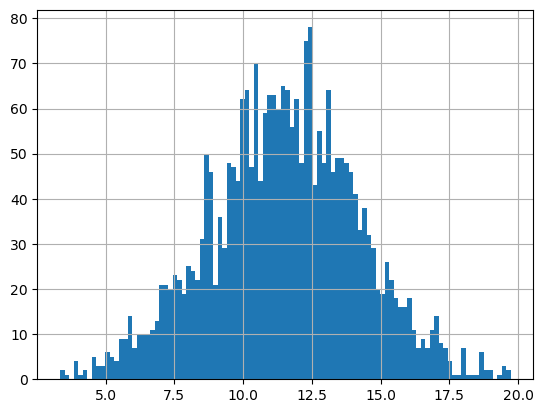

In [35]:
manejo.TAH.hist(bins=100)

In [36]:

fig = go.Figure(data=go.Violin(y=manejo['TAH'], box_visible=True, line_color='black',
                               meanline_visible=True, fillcolor='violet', opacity=0.6,
                               x0='TAH'))

fig.update_layout(yaxis_zeroline=False)
fig.show()

* las ditribuciones son simetricas, lo que va a una distribucion equilibrada... pero que se hara con los outliers? ... yo los quitaria!!, pero si son importantes? en la lit se usa un metodo llamado winsorized.. es acercar los extremos a valores mas representativos!!

# INTEGRACION

In [68]:
ndvi['Zafra'] = ndvi['Zafra'].str.replace('zafra ', '', case=False, regex=True)
ndvi

,ID_LOTE,Zafra,Fecha de Inicio,Fecha de Cierra,max_max,mean_media,delta
0,1,2020-2021,2020-01-16 21:36:00,2021-01-07,0.7904,0.610817,0.1275
1,1,2021-2022,2021-01-05 12:00:00,2021-12-09,0.7991,0.532957,0.0318
2,1,2022-2023,2022-01-25 16:48:00,2023-03-22,0.7739,0.579371,-0.0283
3,1,2023-2024,2023-04-06 16:48:00,2024-03-26,0.8143,0.610222,-0.0826
4,2,2020-2021,2020-05-03 02:24:00,2021-05-14,0.8094,0.658218,-0.1087
...,...,...,...,...,...,...,...
33671,13165,2021-2022,2021-05-16 21:36:00,2022-03-21,0.7486,0.587889,-0.2271
33672,13165,2022-2023,2022-03-20 21:36:00,2023-03-15,0.7372,0.527633,0.0147
33673,13165,2023-2024,2023-03-14 02:24:00,2024-04-08,0.7493,0.616427,0.1278
33674,13166,2023-2024,2023-02-28 02:24:00,2024-03-04,0.8450,0.711480,-0.0553


In [73]:
len(manejo)

2540

In [74]:
df_cana = manejo.merge(ndvi.rename(columns={'ID_LOTE':'ID-Unidad de producción'}), on=['ID-Unidad de producción', 'Zafra'], how='inner').reset_index(drop=True)

## correlacion entre variables numericas


In [82]:
df_cana.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2336 entries, 0 to 2335
Data columns (total 39 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Zafra                                            2336 non-null   object        
 1   ID-Unidad de producción                          2336 non-null   int64         
 2   Zona Longitudinal                                2336 non-null   object        
 3   Estrato                                          2336 non-null   object        
 4   Fecha Inicial                                    2336 non-null   datetime64[ns]
 5   Fecha de Cierre                                  2336 non-null   datetime64[ns]
 6   Suelo                                            1823 non-null   object        
 7   Edad (meses)                                     2336 non-null   float64       
 8   Variedad                              

In [76]:
numeric_columns_select = [ 'Edad (meses)', 'Nitrogeno (Kg/ha)',
       'Potasio (Kg/ha)', 'Fósforo (Kg/ha)', 'TCH', 'Rendimiento (%)', 'TAH',
       'Pureza (%)', 'Radiación global acumulada (W/m2)',
       'Precipitación acumulada por ciclo/Estación (mm)',
       'Temperatura mínima (30DAC) °C', 'Temperatura máxima (30DAC) °C',
       'Amplitud térmica (30DAC) °C', 'Precipitación agosto (mm)','max_max', 'mean_media', 'delta'
       ]

In [79]:
df_cana[[ 'Edad (meses)', 'Nitrogeno (Kg/ha)',
       'Potasio (Kg/ha)', 'Fósforo (Kg/ha)', 'TCH', 'Rendimiento (%)', 'TAH',
       'Pureza (%)', 'Radiación global acumulada (W/m2)',
       'Precipitación acumulada por ciclo/Estación (mm)',
       'Temperatura mínima (30DAC) °C', 'Temperatura máxima (30DAC) °C',
       'Amplitud térmica (30DAC) °C', 'Precipitación agosto (mm)','max_max', 'mean_media', 'delta'
       ]]

,Edad (meses),Nitrogeno (Kg/ha),Potasio (Kg/ha),Fósforo (Kg/ha),TCH,Rendimiento (%),TAH,Pureza (%),Radiación global acumulada (W/m2),Precipitación acumulada por ciclo/Estación (mm),Temperatura mínima (30DAC) °C,Temperatura máxima (30DAC) °C,Amplitud térmica (30DAC) °C,Precipitación agosto (mm),max_max,mean_media,delta
0,11.31,76.80,0.0,0.00,53.09,10.91,5.79,91.50,71508.07427,3271.2,22.300000,31.716667,9.416667,730.2,0.7578,0.650500,0.0439
1,10.88,78.57,0.0,0.00,69.12,10.18,7.04,91.20,68918.21800,3268.2,22.300000,31.716667,9.416667,730.2,0.7769,0.606043,-0.0291
2,11.11,81.80,0.0,0.00,62.88,10.01,6.29,90.06,70350.41280,3266.2,22.343333,31.733333,9.390000,730.2,0.6788,0.580217,-0.0485
3,11.24,81.80,0.0,0.00,67.47,11.07,7.47,90.27,71021.27947,3269.0,22.390000,31.726667,9.336667,730.2,0.7406,0.588433,-0.1130
4,11.21,81.80,0.0,0.00,62.72,9.46,5.93,88.53,70938.46384,3266.4,22.343333,31.733333,9.390000,730.2,0.7929,0.616983,0.0060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2331,11.44,92.47,0.0,0.00,118.73,10.77,12.79,84.68,77805.93263,1870.2,23.720000,38.096667,14.376667,278.4,0.7885,0.625780,-0.1312
2332,11.41,77.45,0.0,0.00,126.60,10.64,13.47,85.11,77569.51596,1825.2,23.720000,38.096667,14.376667,278.4,0.7564,0.631700,-0.1152
2333,12.23,92.23,0.0,0.00,64.78,10.91,7.07,84.94,83131.02953,2000.0,23.916667,38.103333,14.186667,278.4,0.7611,0.645809,-0.1016
2334,12.20,114.59,0.0,0.00,74.37,9.94,7.39,84.45,85633.28883,1282.6,25.340000,37.166667,11.826667,185.8,0.6943,0.613950,-0.1395


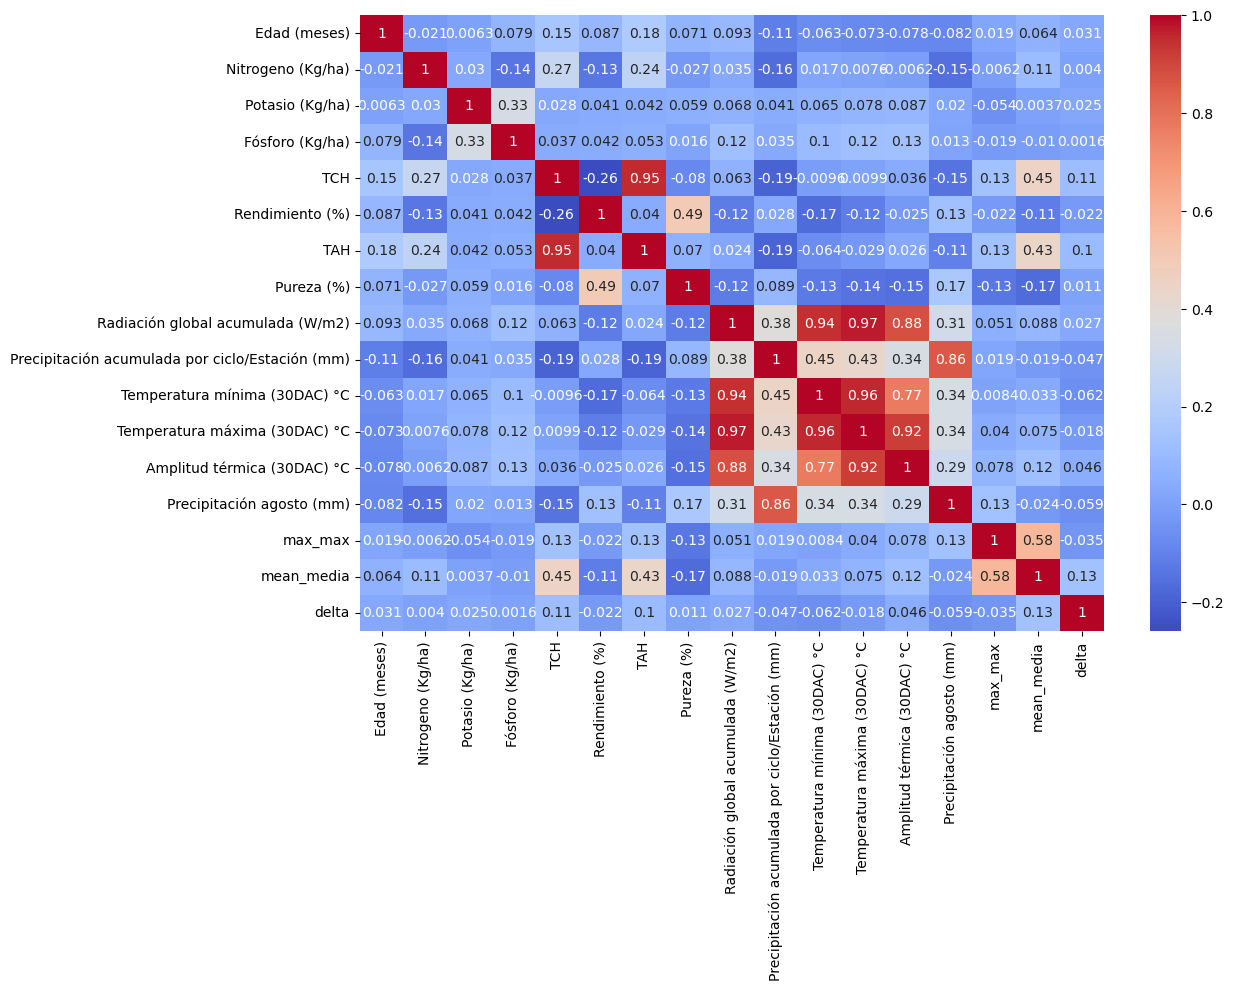

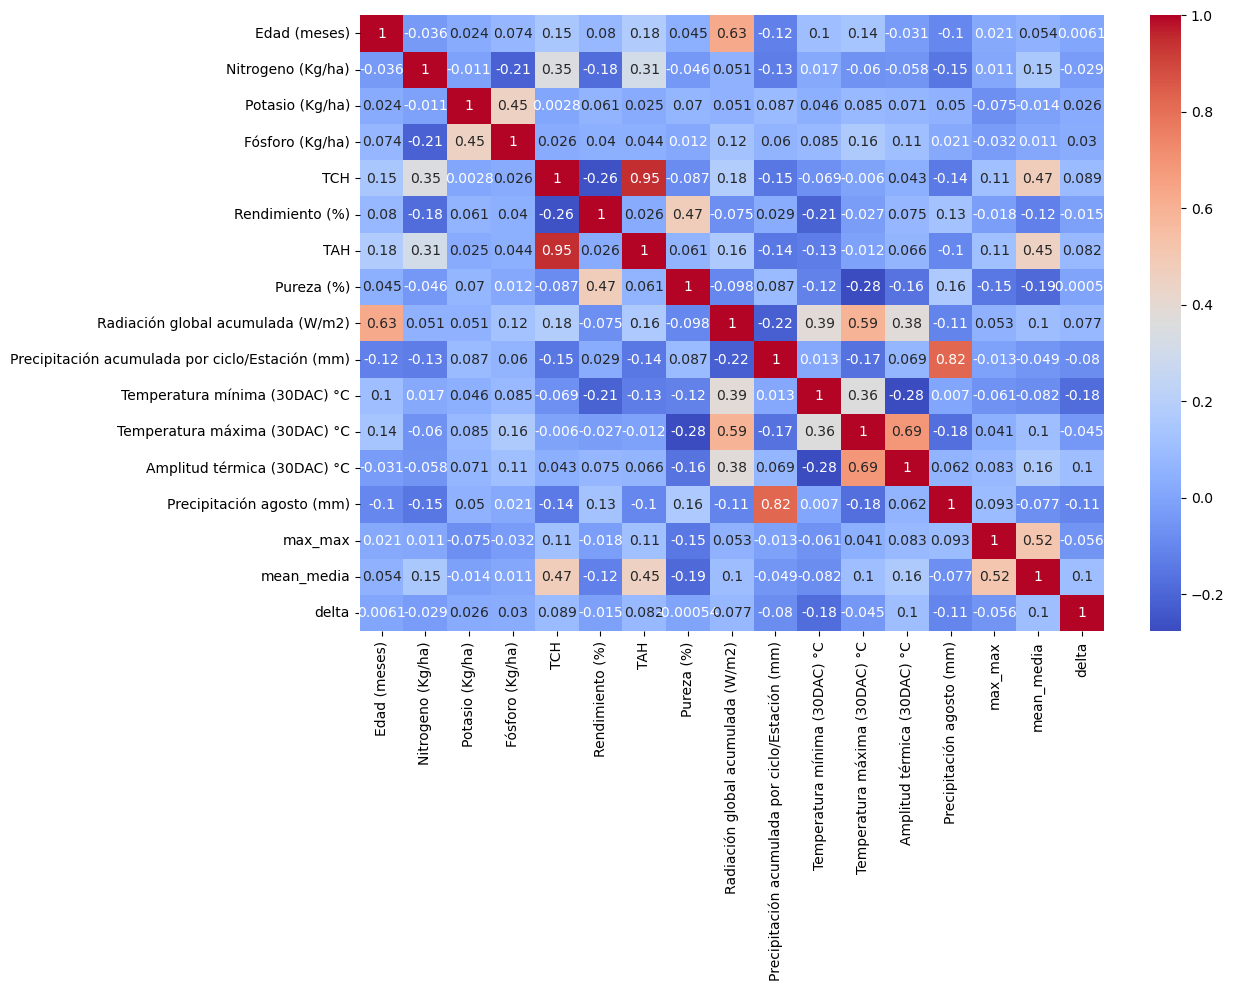

In [83]:
# con pearson--- lineal
corr_matrix = df_cana[numeric_columns_select].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

corr_matrix = df_cana[numeric_columns_select].corr(method='spearman')
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()


la precipitacion de agosto es crucial para la acumulada por ciclo!!
* la caña esta en etapa de crecimiento
*canicula es entre julio y agosto!!!
* se relaciona con la canicula--- afecta la producción en la última cola de la cosecha
*agua en los primeros meses (antes y despues) con el TCH y TAH
*existe el número de riegos??...zonas mas secas mas aplicaciones/ suelos tipo arenosa hay menos retenc
*Hipotesis: si hay mas lluvia habra mas concentracion de azucar? o si hay mas lluvia se "usa" para seguir creciendo?

## Relacion entre variables

In [84]:
numeric_columns_select

['Edad (meses)',
 'Nitrogeno (Kg/ha)',
 'Potasio (Kg/ha)',
 'Fósforo (Kg/ha)',
 'TCH',
 'Rendimiento (%)',
 'TAH',
 'Pureza (%)',
 'Radiación global acumulada (W/m2)',
 'Precipitación acumulada por ciclo/Estación (mm)',
 'Temperatura mínima (30DAC) °C',
 'Temperatura máxima (30DAC) °C',
 'Amplitud térmica (30DAC) °C',
 'Precipitación agosto (mm)',
 'max_max',
 'mean_media',
 'delta']

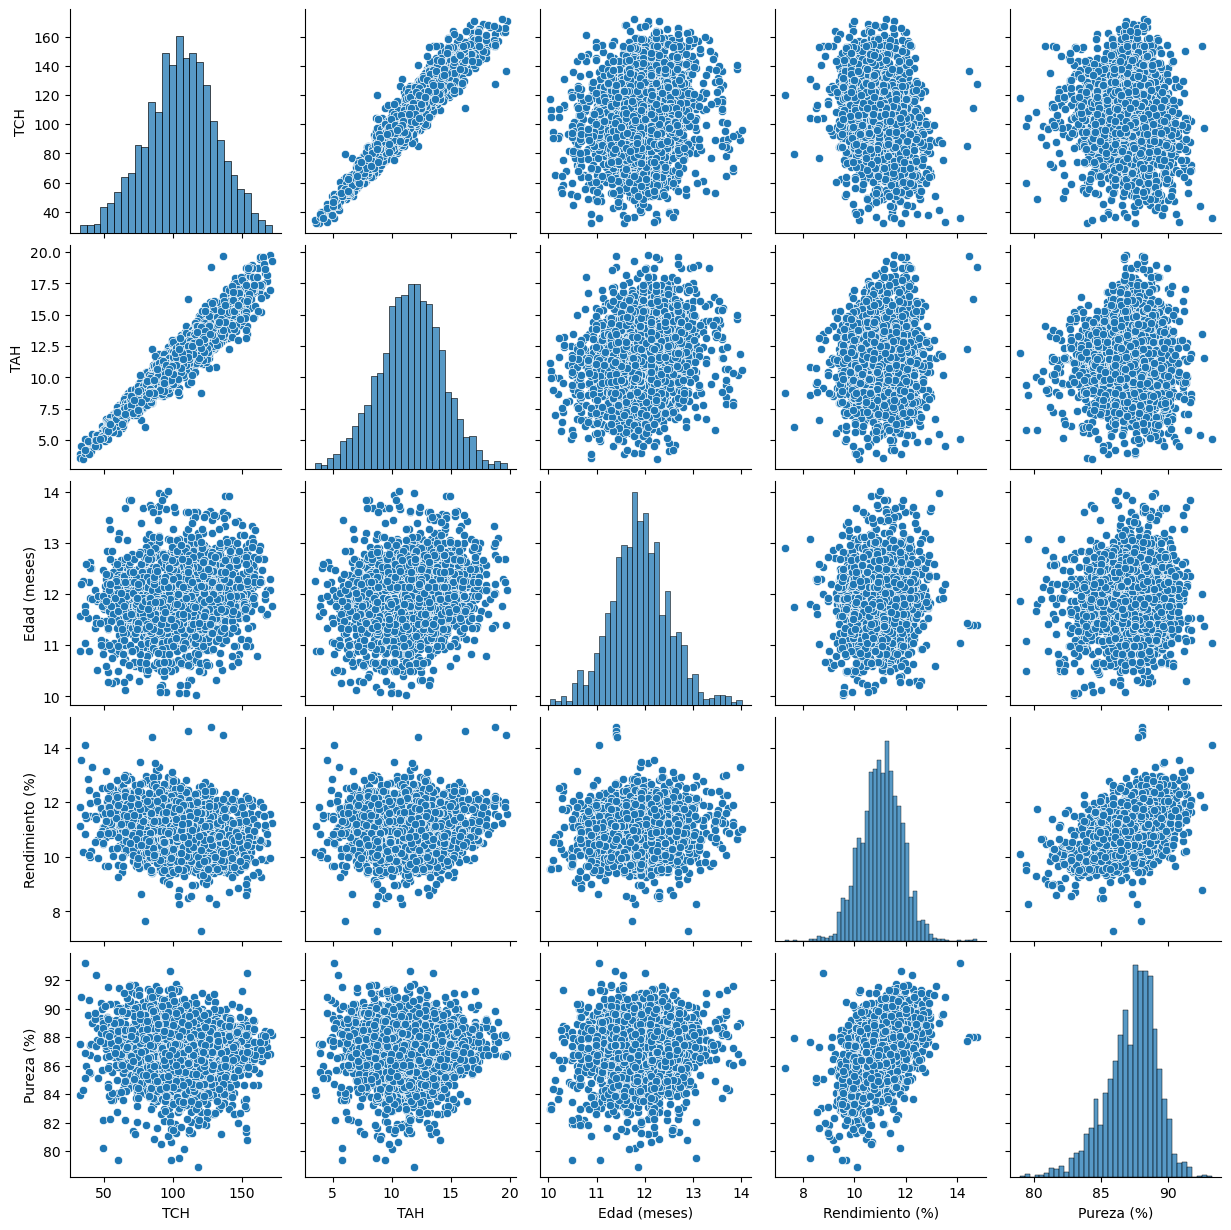

In [85]:
sns.pairplot(df_cana[['TCH', 'TAH', 'Edad (meses)',  'Rendimiento (%)', 'Pureza (%)', 'No.Corte']])
plt.show()

## Hipotesis: el numero de corte influye en el TCH y TAH

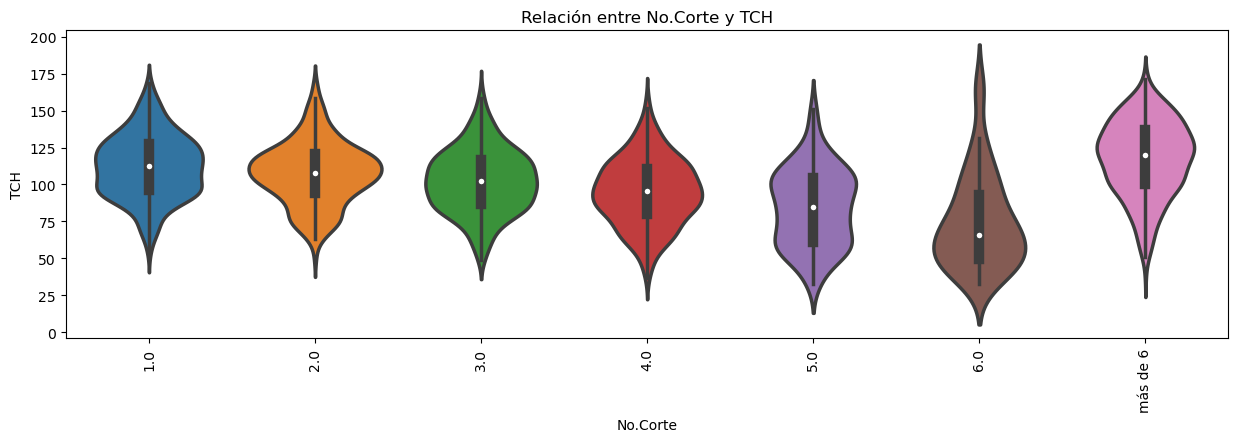

In [86]:
plt.figure(figsize=(15, 4))

sns.violinplot(x='No.Corte', y='TCH', data=df_cana, 
               inner='box', 
               linewidth=2.5) 


plt.xticks(rotation=90)
plt.title('Relación entre No.Corte y TCH')
plt.show()


In [91]:
df_cana['No.Corte'].unique()

[5.0, 4.0, 3.0, 'más de 6', 2.0, 6.0, 1.0]
Categories (7, object): [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 'más de 6']

In [93]:

orden_corte = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 'más de 6']


colors = n_colors('rgb(5, 200, 200)', 'rgb(200, 10, 10)', len(orden_corte), colortype='rgb')

# Crear el gráfico de violines
fig = go.Figure()


for corte, color in zip(orden_corte, colors):
    if corte in df_cana['No.Corte'].unique():  # Verificar si la categoría existe en los datos
        fig.add_trace(go.Violin(
            x=df_cana[df_cana['No.Corte'] == corte]['TAH'],  # TCH por categoría de No.Corte
            name=str(corte),  # Nombre de la categoría
            line_color=color,  # Color del violín
            meanline_visible=True,  # Mostrar la línea de la media
            meanline=dict(color='black', width=2),  
            box_visible=True,  
            box_line=dict(color='blue', width=1),  
        ))


fig.update_traces(orientation='h', side='positive', width=1.8, points=False)  # Violin orientado horizontal
fig.update_layout(
    xaxis_showgrid=False, 
    xaxis_zeroline=False, 
    title="Distribución de TCH por No.Corte", 
    yaxis_title="No.Corte", 
    xaxis_title="TCH",
    yaxis={'categoryorder': 'array', 'categoryarray': orden_corte},  # Ordenar los violines según 'orden_corte'
    height=1000,  # Ajustar la altura 
    width=1000  # Ajustar el ancho 
)


fig.show()


In [94]:

for corte, color in zip(orden_corte, colors):
    if corte in df_cana['No.Corte'].unique():  # Verificar si la categoría existe en los datos
        fig.add_trace(go.Violin(
            x=df_cana[df_cana['No.Corte'] == corte]['TAH'],  # TCH por categoría de No.Corte
            name=str(corte),  # Nombre de la categoría
            line_color=color,  # Color del violín
            meanline_visible=True,  # Mostrar la línea de la media
            meanline=dict(color='black', width=2),  # Personalización de la línea de la media
            box_visible=True,  
            box_line=dict(color='blue', width=1), 
            points='all',  # Mostrar todos los puntos de datos 
            pointpos=0,  # Ubicar los puntos en el centro del violín
            jitter=0.3,  # Añadir dispersión a los puntos para que no se superpongan
            marker=dict(size=3, opacity=0.6)  #  los puntos
        ))


fig.update_traces(orientation='h', side='positive', width=1.1)  # Violin orientado horizontal
fig.update_layout(
    xaxis_showgrid=False, 
    xaxis_zeroline=False, 
    title="Distribución de TCH por No.Corte", 
    yaxis_title="No.Corte", 
    xaxis_title="TCH",
    yaxis={'categoryorder': 'array', 'categoryarray': orden_corte},  # Ordenar 
    height=1000, 
    width=1000  
)

fig.show()


entre menos socas mas TCH o TAC...

In [36]:
## Nutrientes

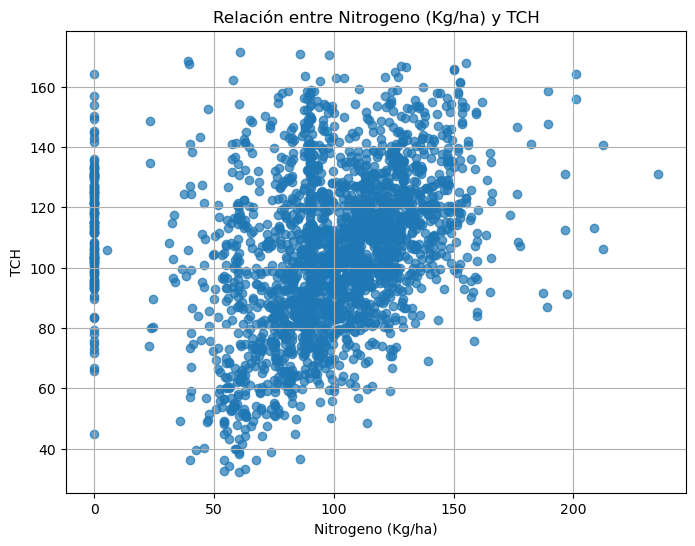

In [96]:
plt.figure(figsize=(8,6))
plt.scatter(df_cana['Nitrogeno (Kg/ha)'], df_cana['TCH'], alpha=0.7)
plt.title('Relación entre Nitrogeno (Kg/ha) y TCH')
plt.xlabel('Nitrogeno (Kg/ha)')
plt.ylabel('TCH')
plt.grid(True)
plt.show()

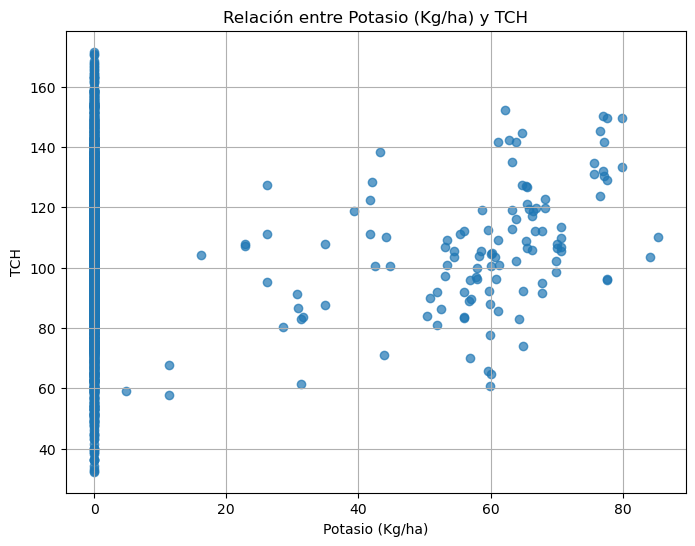

In [97]:
plt.figure(figsize=(8,6))
plt.scatter(df_cana['Potasio (Kg/ha)'], df_cana['TCH'], alpha=0.7)
plt.title('Relación entre Potasio (Kg/ha) y TCH')
plt.xlabel('Potasio (Kg/ha)')
plt.ylabel('TCH')
plt.grid(True)
plt.show()

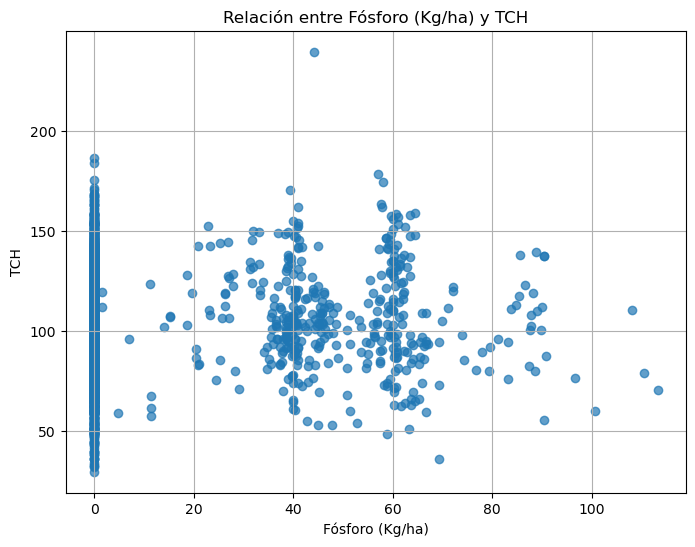

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(data['Fósforo (Kg/ha)'], data['TCH'], alpha=0.7)
plt.title('Relación entre Fósforo (Kg/ha) y TCH')
plt.xlabel('Fósforo (Kg/ha)')
plt.ylabel('TCH')
plt.grid(True)
plt.show()

Relaciones

In [100]:
# Crear un gráfico de dispersión usando Plotly
fig = px.scatter(
    data_frame=df_cana,
    x='Pureza (%)',             
    y='TCH',                   
    color='Precipitación acumulada por ciclo/Estación (mm)', 
    labels={
        'nvdi_prom': 'NVDI Promedio',
        'TCH': 'TCH',
        'Precipitación acumulada por ciclo/Estación (mm)': 'Precipitación acumulada por ciclo/Estación (mm)'
    },
    title='Relación entre TCH y pureza y Precipitación acumulada por ciclo/Estación (mm)'
)


fig.show()

In [102]:
df_cana.columns

Index(['Zafra', 'ID-Unidad de producción', 'Zona Longitudinal', 'Estrato',
       'Fecha Inicial', 'Fecha de Cierre', 'Suelo', 'Edad (meses)', 'Variedad',
       'No.Corte', 'Nitrogeno (Kg/ha)', 'Potasio (Kg/ha)', 'Fósforo (Kg/ha)',
       'TCH', 'Rendimiento (%)', 'TAH', 'Pureza (%)',
       'Radiación global acumulada (W/m2)',
       'Precipitación acumulada por ciclo/Estación (mm)',
       'Temperatura mínima (30DAC) °C', 'Temperatura máxima (30DAC) °C',
       'Amplitud térmica (30DAC) °C', 'Precipitación agosto (mm)',
       'Iniciación_radiacion_acumulada', 'Macollamiento_radiacion_acumulada',
       'Elongación I_radiacion_acumulada', 'Elongacíon II_radiacion_acumulada',
       'Maduración_radiacion_acumulada', 'Iniciación_prec_acumulada',
       'Macollamiento_prec_acumulada', 'Elongación I_prec_acumulada',
       'Elongacíon II_prec_acumulada', 'Maduración_prec_acumulada', 'textura',
       'Fecha de Inicio', 'Fecha de Cierra', 'max_max', 'mean_media', 'delta'],
      dtype='o

In [106]:


# Crear un gráfico de dispersión usando Plotly
fig = px.scatter(
    data_frame=df_cana,
    x='delta',             
    y='TCH',                   
    color='Precipitación acumulada por ciclo/Estación (mm)', 
    labels={
        'nvdi_prom': 'NVDI Promedio',
        'TCH': 'TCH',
        'Precipitación acumulada por ciclo/Estación (mm)': 'Precipitación acumulada por ciclo/Estación (mm)'
    },
    title='Relación entre TCH y NVDI y Precipitación acumulada por ciclo/Estación (mm)'
)


fig.show()
